## https://github.com/2Myaka2/DataScience_projects

### работал в репозитории

# Поведенческий скоринг клиентов банка: прогноз риска просрочки 90+ дней

## Подготовка рабочего пространства

* Дайте этой тетрадке Jupyter название, которое корректно отражает суть проекта.
* Опишите постановку задачи своими словами, коротко зафиксировав основной смысл.
* Опишите данные, которые даны для решения задачи.

## Подготовка рабочего пространства

### Постановка задачи

В рамках проекта решается задача поведенческого скоринга клиентов банка. Необходимо построить модель, которая по данным о клиенте на конкретную дату скоринга будет прогнозировать вероятность возникновения просрочки платежа по кредиту длительностью 90 дней и более.

Объектом моделирования является не клиент в целом, а пара «клиент — месяц наблюдения». Для каждого клиента в каждый месяц необходимо определить, возникнет ли у него просрочка 90+ дней в течение следующих 12 месяцев. Если такая просрочка возникает, целевая переменная принимает значение `1`, если не возникает — `0`.

Практический смысл задачи состоит в том, чтобы заранее выявлять клиентов с повышенным риском дефолта. Это позволит банку точнее управлять кредитным риском, резервами и ликвидностью: не пропускать действительно рискованных клиентов, но при этом не относить к зоне риска слишком большую долю надёжных клиентов.

### Описание данных

Для решения задачи предоставлены несколько таблиц с данными о клиентах, кредитах, транзакциях, просрочках и макроэкономических условиях.

| Таблица | Содержание |
|---|---|
| `ds_15_cohort_grid.csv` | Даты проведения поведенческого скоринга. Содержит идентификатор клиента `ID` и дату скоринга `score_date`. Эта таблица задаёт базовую сетку наблюдений «клиент — месяц». |
| `ds_15_loan_payment_credit.csv` | Данные о просрочках платежей: идентификатор клиента, дата начала периода просрочки и количество дней просрочки. На основе этой таблицы будет формироваться целевая переменная. |
| `ds_15_transactions.csv` | Помесячные транзакции клиента по MCC-кодам: траты в маркетплейсах, фастфуде, ресторанах, супермаркетах, сервисах Яндекса, магазинах бытовой техники, ЖКУ и прочих категориях. |
| `ds_15_client_description.csv` | Социально-демографическое описание клиента на момент регистрации в банке: возраст, семейное положение, наличие иждивенцев, дата регистрации. |
| `ds_15_credit_description.csv` | Описание кредита: месячный доход клиента и сумма выданного кредита. |
| `ds_15_mortgage_presence.csv` | Информация о наличии ипотеки: дата открытия ипотеки и признак наличия ипотеки. |
| `ds_15_credit_rating.csv` | Динамика кредитного рейтинга клиента по датам. |
| `ds_15_macro_data.csv` | Макроэкономические показатели по месяцам: учётная ставка, уровень безработицы и инфляция. |

Перед моделированием все источники данных будут объединены в единую таблицу наблюдений. При объединении будет важно учитывать временную структуру данных: в признаках для каждой строки должны использоваться только те данные, которые были доступны на дату скоринга.

## Перевод бизнес-задачи на язык машинного обучения

* Напишите, что конкретно будете делать, пользуясь терминами машинного обучения:
  * какие модели будете использовать;
  * какие методы работы с данными применять;
  * как планируете решать поставленную задачу.


## Перевод бизнес-задачи на язык машинного обучения

С точки зрения машинного обучения задача является задачей бинарной классификации.

Для каждой строки итоговой таблицы, соответствующей клиенту в конкретный месяц, необходимо предсказать целевую переменную:

- `1` — в течение следующих 12 месяцев у клиента возникнет просрочка платежа длительностью 90 дней и более;
- `0` — в течение следующих 12 месяцев такой просрочки не возникнет.

В качестве признаков будут использоваться социально-демографические характеристики клиента, параметры кредита, история транзакций, сведения об ипотеке, динамика кредитного рейтинга, информация о текущих и прошлых просрочках, а также макроэкономические показатели.

### План решения

Сначала будет проведена загрузка и первичный анализ всех таблиц: проверка типов данных, пропусков, дубликатов, выбросов и временных диапазонов. После этого будет сформирована единая таблица наблюдений на основе `cohort_grid`, где каждая строка соответствует паре «клиент — дата скоринга».

Особое внимание будет уделено корректному формированию целевой переменной. Для каждой даты скоринга будет проверяться, возникла ли у клиента просрочка 90+ дней в течение следующих 12 месяцев. При этом признаки должны строиться только на основе информации, доступной на момент скоринга, чтобы избежать утечки данных из будущего.

Для повышения качества модели будут созданы дополнительные признаки, например:

- отношение суммы кредита к доходу клиента;
- срок жизни клиента в банке на дату скоринга;
- агрегированные признаки по транзакциям;
- признаки динамики кредитного рейтинга;
- признаки, связанные с наличием ипотеки и семейной нагрузкой.

После подготовки данных будет проанализирован баланс классов в целевой переменной. Так как дефолты обычно встречаются существенно реже, чем нормальные платежи, задача, вероятно, будет несбалансированной. Поэтому будут рассмотрены методы балансировки классов: `class_weight`, `RandomOverSampler`, `RandomUnderSampler` или `SMOTE`.

### Модели

На базовом этапе будут обучены и сравнены несколько вариантов моделей:

1. логистическая регрессия без балансировки классов;
2. случайный лес без балансировки классов;
3. логистическая регрессия с балансировкой классов;
4. случайный лес с балансировкой классов.

Для итогового решения будет использована ансамблевая модель `RandomForestClassifier`, так как она способна учитывать нелинейные зависимости между признаками, работает с признаками разного масштаба и позволяет оценить важность признаков через `feature_importances_`.

Подбор гиперпараметров итоговой модели будет выполнен с помощью `Optuna`. Для валидации будет использоваться кросс-валидация на трёх фолдах с учётом временной структуры данных и группировки по клиентам через `GroupTimeSeriesSplit`.

### Оценка качества

Качество моделей будет оцениваться как техническими, так и бизнес-метриками.

В качестве технической метрики для сравнения моделей будет использоваться ROC-AUC или accuracy. Однако основное внимание будет уделено бизнес-метрикам:

- `approval rate` — доля клиентов, которых модель считает надёжными;
- `default rate` — доля фактических дефолтов среди клиентов, признанных моделью надёжными;
- `missed defaults rate` — доля дефолтов, которые модель пропустила.

После обучения лучшей модели будет проведена калибровка вероятностей на отдельной калибровочной выборке. Затем будет подобран порог классификации, при котором одновременно выполняются бизнес-ограничения:

- `approval rate` не менее 65%;
- `default rate` не более 2%;
- `missed defaults rate` не более 4%.

Финальная проверка качества будет выполнена на тестовой выборке, которая не будет использоваться ни при обучении модели, ни при подборе гиперпараметров, ни при калибровке, ни при выборе порога. Это позволит оценить, насколько стабильно модель работает на новых данных.

## Загрузка необходимых библиотек

* Загрузите все библиотеки, необходимые для выполнения проекта.

In [262]:
%%writefile requirements.txt
numpy==1.26.4
pandas==2.2.3
scipy==1.13.1

scikit-learn==1.6.1
imbalanced-learn==0.13.0
mlxtend==0.23.4

matplotlib==3.10.8
seaborn==0.13.2

joblib==1.5.3
ipykernel==6.29.5
optuna==4.4.0

Overwriting requirements.txt


In [263]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [384]:
# Базовые библиотеки
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn: базовые инструменты
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Кросс-валидация с учётом групп и времени
from mlxtend.evaluate import GroupTimeSeriesSplit

# sklearn: предобработка
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# sklearn: признаки
from sklearn.feature_selection import VarianceThreshold

# sklearn: модели классификации
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Балансировка классов
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

# sklearn: калибровка вероятностей
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# sklearn: метрики классификации
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    brier_score_loss
)

# Optuna
import optuna
from optuna.samplers import TPESampler

# Настройки отображения
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid")

# Константы проекта
RANDOM_STATE = 42
CV_FOLDS = 3

TARGET = "target"
ID_COL = "ID"
SCORE_DATE_COL = "score_date"

DEFAULT_START_COL = "дата_начала_периода"
DEFAULT_DAYS_COL = "просрочка_дней"

HORIZON_MONTHS = 12
CALIBRATION_MONTHS = 12
TEST_MONTHS = 12
DEFAULT_DAYS_THRESHOLD = 90
HORIZON_DAYS = 365

# Бизнес-ограничения по итоговому порогу
MIN_APPROVAL_RATE = 0.65
MAX_DEFAULT_RATE = 0.02
MAX_MISSED_DEFAULTS_RATE = 0.04

# Пути к данным
DATA_DIR = Path("datasets")

## Загрузка данных

* Загрузите предоставленные датасеты. Обратите внимание на то, как загрузятся данные, в каком формате представлены таблицы. Пути к данным:
  * `'/datasets/ds_15_loan_payment_credit.csv'`;
  * `'/datasets/ds_15_transactions.csv'`;
  * `'/datasets/ds_15_client_description.csv'`;
  * `'/datasets/ds_15_credit_description.csv'`;
  * `'/datasets/ds_15_mortgage_presence.csv'`;
  * `'/datasets/ds_15_credit_rating.csv'`;
  * `'/datasets/ds_15_macro_data.csv'`;
  * `'/datasets/ds_15_cohort_grid.csv'`.
* Посмотрите на содержимое таблиц. Сделайте первые выводы о них.

In [265]:
REMOTE_DATA_URL = "https://code.s3.yandex.net/datasets/"

file_names = {
    "cohort_grid": "ds_15_cohort_grid.csv",
    "loan_payment_credit": "ds_15_loan_payment_credit.csv",
    "transactions": "ds_15_transactions.csv",
    "client_description": "ds_15_client_description.csv",
    "credit_description": "ds_15_credit_description.csv",
    "mortgage_presence": "ds_15_mortgage_presence.csv",
    "credit_rating": "ds_15_credit_rating.csv",
    "macro_data": "ds_15_macro_data.csv",
}

dataframes = {}

for name, file_name in file_names.items():
    local_path = DATA_DIR / file_name                  # локальная папка проекта
    practicum_path = Path("/datasets") / file_name     # путь на платформе Практикума
    remote_path = REMOTE_DATA_URL + file_name          # удалённый путь
    
    try:
        dataframes[name] = pd.read_csv(local_path)
        print(f"{name}: загружен из локальной папки {local_path}")
    except FileNotFoundError:
        try:
            dataframes[name] = pd.read_csv(practicum_path)
            print(f"{name}: загружен из папки Практикума {practicum_path}")
        except FileNotFoundError:
            dataframes[name] = pd.read_csv(remote_path)
            print(f"{name}: загружен из удалённого хранилища")

cohort_grid: загружен из локальной папки datasets/ds_15_cohort_grid.csv
loan_payment_credit: загружен из локальной папки datasets/ds_15_loan_payment_credit.csv
transactions: загружен из локальной папки datasets/ds_15_transactions.csv
client_description: загружен из локальной папки datasets/ds_15_client_description.csv
credit_description: загружен из локальной папки datasets/ds_15_credit_description.csv
mortgage_presence: загружен из локальной папки datasets/ds_15_mortgage_presence.csv
credit_rating: загружен из локальной папки datasets/ds_15_credit_rating.csv
macro_data: загружен из локальной папки datasets/ds_15_macro_data.csv


In [266]:
cohort_grid = dataframes["cohort_grid"]
loan_payment_credit = dataframes["loan_payment_credit"]
transactions = dataframes["transactions"]
client_description = dataframes["client_description"]
credit_description = dataframes["credit_description"]
mortgage_presence = dataframes["mortgage_presence"]
credit_rating = dataframes["credit_rating"]
macro_data = dataframes["macro_data"]

In [267]:
# Словарь с исходными таблицами проекта
df_mains = {
    "cohort_grid": cohort_grid,
    "loan_payment_credit": loan_payment_credit,
    "transactions": transactions,
    "client_description": client_description,
    "credit_description": credit_description,
    "mortgage_presence": mortgage_presence,
    "credit_rating": credit_rating,
    "macro_data": macro_data,
}

In [268]:
def show_df_info(name, df, head_rows=5):
    print("=" * 100)
    print(f"Датасет: {name}")
    print("=" * 100)

    print("\nИнформация о типах данных:")
    df.info()

    print("\nПервые строки:")
    display(df.head(head_rows))

    print("\nСводка по столбцам:")
    columns_info = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "non_null_values": df.notna().sum().values,
        "missing_values": df.isna().sum().values,
        "missing_percent": (df.isna().mean() * 100).round(2).values,
        "unique_values": df.nunique(dropna=False).values,
    })

    display(columns_info)

    print("\nПропуски:")
    missing_info = columns_info[columns_info["missing_values"] > 0].copy()

    if missing_info.empty:
        print("Пропусков не обнаружено.")
    else:
        display(
            missing_info[
                ["column", "missing_values", "missing_percent"]
            ].sort_values("missing_percent", ascending=False)
        )

    print("\nКоличество явных дубликатов:")
    duplicated_count = df.duplicated().sum()
    duplicated_percent = duplicated_count / len(df) * 100 if len(df) > 0 else 0
    print(f"{duplicated_count} строк ({duplicated_percent:.2f}%)")

    if ID_COL in df.columns:
        print("\nИнформация по ID:")
        print(f"Уникальных клиентов: {df[ID_COL].nunique()}")
        print(f"Всего строк: {len(df)}")
        print(f"Среднее количество строк на клиента: {len(df) / df[ID_COL].nunique():.2f}")

    date_like_columns = [
        col for col in df.columns
        if col.lower() in ["date", "score_date"] or "дата" in col.lower()
    ]

    if date_like_columns:
        print("\nПроверка столбцов с датами:")
        for col in date_like_columns:
            parsed_dates = pd.to_datetime(df[col], errors="coerce")
            parse_errors = parsed_dates.isna().sum() - df[col].isna().sum()

            print(f"\nСтолбец: {col}")
            print(f"Минимальная дата: {parsed_dates.min()}")
            print(f"Максимальная дата: {parsed_dates.max()}")
            print(f"Не удалось распарсить значений: {parse_errors}")

    numeric_columns = df.select_dtypes(include=np.number).columns

    if len(numeric_columns) > 0:
        print("\nОписательная статистика по числовым признакам:")
        display(df[numeric_columns].describe().T)

    categorical_columns = df.select_dtypes(include=["object", "category", "bool"]).columns

    low_cardinality_info = []

    for col in categorical_columns:
        unique_count = df[col].nunique(dropna=False)

        if unique_count <= 20:
            values = df[col].dropna().unique().tolist()
            low_cardinality_info.append({
                "column": col,
                "unique_values_count": unique_count,
                "values": values,
            })

    if low_cardinality_info:
        print("\nКатегориальные признаки с небольшим числом уникальных значений:")
        display(pd.DataFrame(low_cardinality_info))

    print("\n")

    return {
        "dataset": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "missing_total": df.isna().sum().sum(),
        "duplicated_rows": duplicated_count,
        "memory_mb": df.memory_usage(deep=True).sum() / 1024**2,
    }

In [269]:
datasets_summary = []

for name, df in df_mains.items():
    summary = show_df_info(name, df)
    datasets_summary.append(summary)

datasets_summary = pd.DataFrame(datasets_summary)

print("=" * 100)
print("Общая сводка по исходным таблицам")
print("=" * 100)

display(datasets_summary)

Датасет: cohort_grid

Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   ID          577494 non-null  object
 1   score_date  577494 non-null  object
dtypes: object(2)
memory usage: 8.8+ MB

Первые строки:


,ID,score_date
0,IDF55109846,2013-05-01
1,IDF55109846,2013-06-01
2,IDF55109846,2013-07-01
3,IDF55109846,2013-08-01
4,IDF55109846,2013-09-01



Сводка по столбцам:


,column,dtype,non_null_values,missing_values,missing_percent,unique_values
0,ID,object,577494,0,0.000,13500
1,score_date,object,577494,0,0.000,84



Пропуски:
Пропусков не обнаружено.

Количество явных дубликатов:
0 строк (0.00%)

Информация по ID:
Уникальных клиентов: 13500
Всего строк: 577494
Среднее количество строк на клиента: 42.78

Проверка столбцов с датами:

Столбец: score_date
Минимальная дата: 2013-01-01 00:00:00
Максимальная дата: 2019-12-01 00:00:00
Не удалось распарсить значений: 0


Датасет: loan_payment_credit

Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   5500 non-null   object
 1   дата_начала_периода  5500 non-null   object
 2   просрочка_дней       5500 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 129.0+ KB

Первые строки:


...

,column,dtype,non_null_values,missing_values,missing_percent,unique_values
0,date,object,84,0,0.000,84
1,учетная_ставка,float64,84,0,0.000,40
2,уровень_безработицы,float64,84,0,0.000,18
3,инфляция,float64,84,0,0.000,62



Пропуски:
Пропусков не обнаружено.

Количество явных дубликатов:
0 строк (0.00%)

Проверка столбцов с датами:

Столбец: date
Минимальная дата: 2013-01-01 00:00:00
Максимальная дата: 2019-12-01 00:00:00
Не удалось распарсить значений: 0

Описательная статистика по числовым признакам:


,count,mean,std,min,25%,50%,75%,max
учетная_ставка,84.000,8.639,2.466,5.500,7.250,7.750,10.330,17.000
уровень_безработицы,84.000,5.175,0.409,4.300,4.900,5.200,5.500,6.000
инфляция,84.000,0.528,0.570,-0.540,0.263,0.425,0.635,3.850




Общая сводка по исходным таблицам


,dataset,rows,columns,missing_total,duplicated_rows,memory_mb
0,cohort_grid,577494,2,0,0,65.538
1,loan_payment_credit,5500,3,0,0,0.666
2,transactions,577494,10,0,0,100.786
3,client_description,13500,5,0,0,3.107
4,credit_description,13500,3,0,0,0.979
5,mortgage_presence,6609,3,0,0,0.801
6,credit_rating,577494,3,0,0,69.944
7,macro_data,84,4,0,0,0.007


### Вывод по первичному анализу исходных таблиц

На этапе первичного анализа были загружены и проверены 8 исходных таблиц проекта. В данных не обнаружено явных дубликатов и пропусков: во всех таблицах количество пропущенных значений равно нулю. Это упрощает дальнейшую предобработку, однако часть дат сейчас хранится в формате `object`, поэтому перед объединением таблиц необходимо привести все календарные признаки к типу `datetime`.

Основная таблица наблюдений `cohort_grid` содержит 577 494 строки и 13 500 уникальных клиентов. Каждая строка соответствует клиенту на конкретную дату скоринга. Даты скоринга находятся в диапазоне с января 2013 года по декабрь 2019 года. В среднем на одного клиента приходится около 43 месячных наблюдений, что подтверждает временную структуру данных.

Таблицы `transactions` и `credit_rating` также содержат 577 494 строки и 13 500 уникальных клиентов. Это значит, что по каждой строке из сетки скоринга, вероятно, можно будет присоединить помесячные транзакции и кредитный рейтинг. В таблице транзакций представлены траты по нескольким MCC-категориям. Все признаки числовые, пропусков нет, но распределения расходов имеют заметный разброс: максимальные значения существенно выше медианных, поэтому на следующем этапе стоит проверить выбросы и, возможно, создать агрегированные признаки по общим тратам и долям категорий.

Таблицы `client_description` и `credit_description` содержат по 13 500 строк и по одной записи на каждого клиента. Эти таблицы можно использовать как статические признаки клиента: возраст, семейное положение, наличие иждивенцев, дату регистрации, доход и сумму кредита. Возраст клиентов находится в диапазоне от 18 до 69 лет, а семейное положение имеет три категории: `разведённые`, `нет семьи`, `есть семья`.

Таблица `mortgage_presence` содержит 6 609 клиентов, причём признак `наличие_ипотеки` всегда равен 1. Следовательно, в этой таблице представлены только клиенты, у которых есть ипотека. При объединении с основной таблицей отсутствие клиента в `mortgage_presence` нужно будет интерпретировать как отсутствие ипотеки, то есть заполнить соответствующий признак значением 0. Также важно учитывать дату открытия ипотеки: признак наличия ипотеки должен быть равен 1 только для тех месяцев скоринга, которые не раньше даты открытия.

Таблица `loan_payment_credit` содержит 5 500 клиентов с информацией о просрочках. Количество дней просрочки находится в диапазоне от 80 до 150 дней, среднее значение составляет около 115 дней. Эта таблица будет использоваться для формирования целевой переменной. При этом нельзя просто взять факт наличия клиента в таблице как таргет: для каждой даты скоринга необходимо проверить, возникнет ли просрочка 90+ дней в горизонте следующих 12 месяцев.

Таблица `macro_data` содержит 84 строки, что соответствует помесячным макроэкономическим данным за период с января 2013 года по декабрь 2019 года. В ней представлены учётная ставка, уровень безработицы и инфляция. Эти признаки можно присоединить к основной таблице по месяцу скоринга.

Таким образом, структура данных выглядит согласованной: основная сетка наблюдений, транзакции и кредитный рейтинг имеют одинаковое количество строк и покрывают один и тот же временной диапазон. На следующем этапе необходимо привести даты к типу `datetime`, затем корректно объединить таблицы в единую витрину признаков с учётом временной логики и недопущением утечки данных из будущего.

## Исследовательский анализ данных

* Проведите первичный анализ данных:
    * Проверьте разные характеристики данных.
    * Исследуйте с помощью графиков количественные и категориальные данные.
    * Рекомендуем создать для этого функции, но это необязательное требование.

* Сделайте выводы о выбросах, пропусках, дубликатах и иных аномалиях в данных из каждой таблицы.

* Предобработка данных или их трансформация в этом проекте необязательны — кроме действий, необходимых для объединения таблиц.

In [270]:
def get_date_columns(df):
    date_columns = []

    for col in df.columns:
        col_lower = col.lower()

        if col_lower in ["date", "score_date"] or "дата" in col_lower:
            date_columns.append(col)

    return date_columns


def plot_date_coverage(name, df):
    date_columns = get_date_columns(df)

    if not date_columns:
        return

    for col in date_columns:
        dates = pd.to_datetime(df[col], errors="coerce")
        month_counts = dates.dt.to_period("M").value_counts().sort_index()

        if month_counts.empty:
            continue

        x_values = month_counts.index.to_timestamp()

        plt.figure(figsize=(14, 4))
        plt.plot(x_values, month_counts.values, marker="o")
        plt.title(f"{name}: количество записей по месяцам ({col})")
        plt.xlabel("Месяц")
        plt.ylabel("Количество записей")
        plt.xticks(rotation=45)
        plt.grid(True)
        plt.show()

def plot_numeric_boxplots(name, df, max_cols=12, sample_size=50_000):
    numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

    if not numeric_columns:
        return

    numeric_columns = numeric_columns[:max_cols]
    sample = df[numeric_columns].sample(
        n=min(len(df), sample_size),
        random_state=RANDOM_STATE
    )

    plot_data = pd.DataFrame()

    for col in numeric_columns:
        values = sample[col].dropna()

        if values.empty:
            continue

        skew_value = values.skew()
        use_log = (
            values.min() >= 0
            and pd.notna(skew_value)
            and abs(skew_value) > 2
        )

        new_col_name = f"log1p({col})" if use_log else col
        plot_data[new_col_name] = np.log1p(sample[col]) if use_log else sample[col]

    if plot_data.empty:
        return

    plt.figure(figsize=(14, max(4, 0.6 * len(plot_data.columns))))
    sns.boxplot(data=plot_data, orient="h")
    plt.title(f"{name}: boxplot числовых признаков")
    plt.xlabel("Значение")
    plt.ylabel("Признак")
    plt.show()


def get_categorical_columns(df, max_unique=20):
    date_columns = get_date_columns(df)

    object_columns = [
        col for col in df.select_dtypes(include=["object", "category", "bool"]).columns
        if col != ID_COL and col not in date_columns
    ]

    low_cardinality_numeric_columns = [
        col for col in df.select_dtypes(include=np.number).columns
        if df[col].nunique(dropna=False) <= max_unique
    ]

    categorical_columns = object_columns + low_cardinality_numeric_columns

    return list(dict.fromkeys(categorical_columns))


def plot_categorical_distributions(name, df, max_unique=20, top_n=20):
    categorical_columns = get_categorical_columns(df, max_unique=max_unique)

    if not categorical_columns:
        return

    for col in categorical_columns:
        value_counts = (
            df[col]
            .astype("object")
            .fillna("Пропуск")
            .value_counts()
            .head(top_n)
        )

        plt.figure(figsize=(10, 4))
        sns.barplot(x=value_counts.index.astype(str), y=value_counts.values)
        plt.title(f"{name}: распределение категориального признака {col}")
        plt.xlabel(col)
        plt.ylabel("Количество")
        plt.xticks(rotation=45, ha="right")
        plt.show()

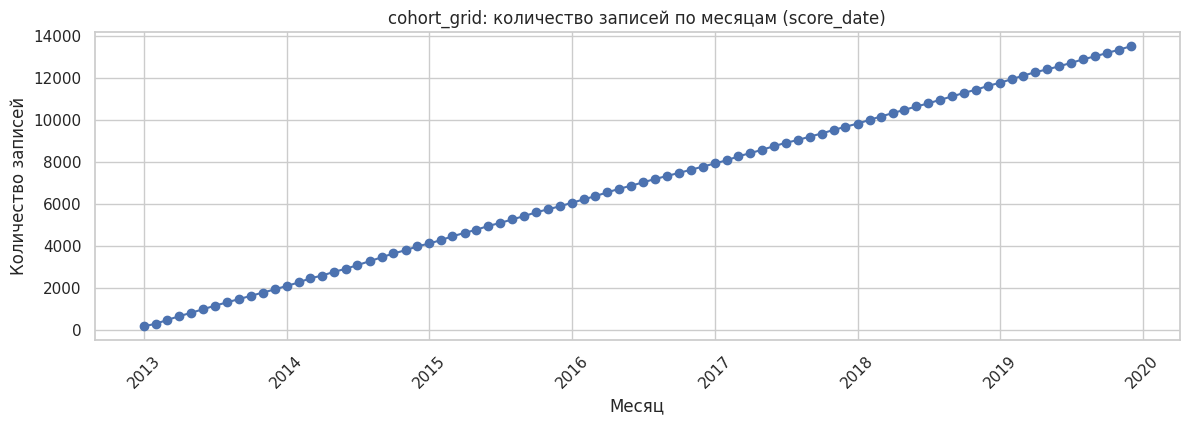

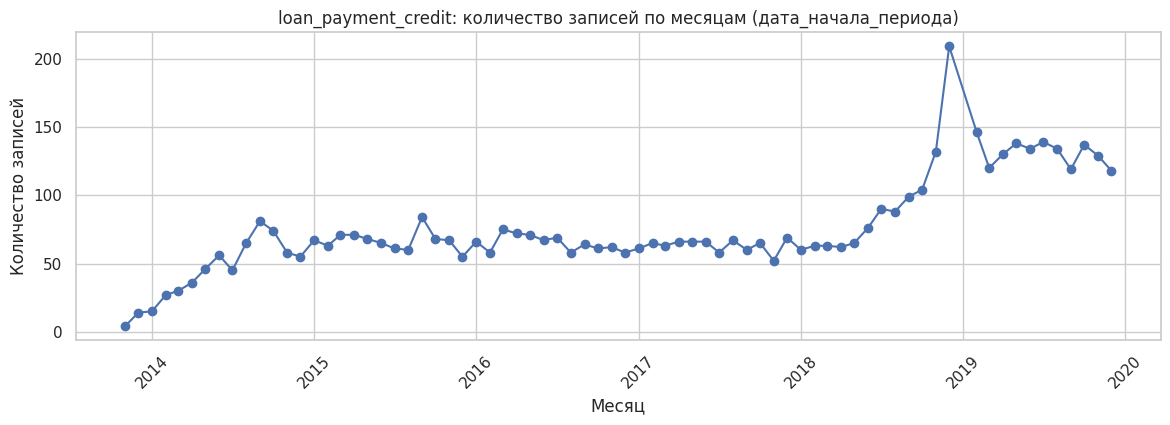

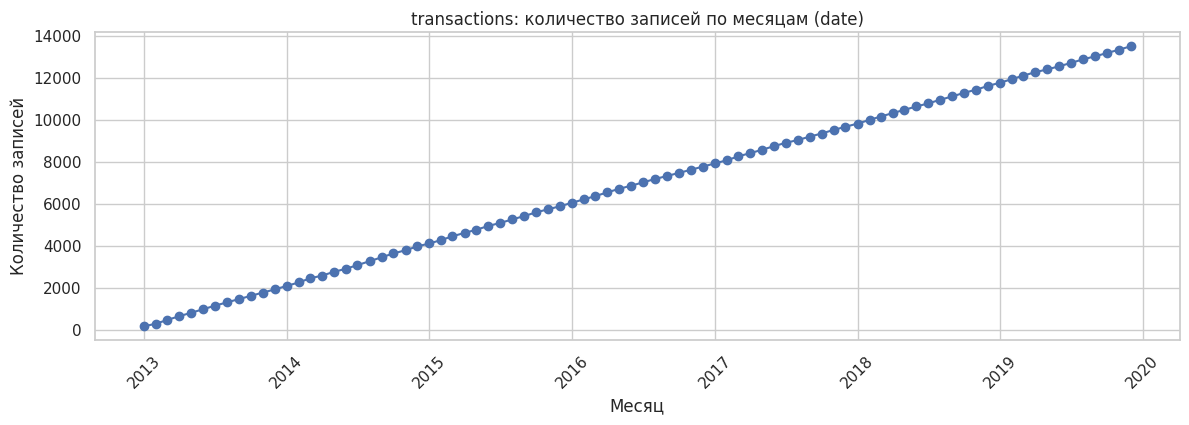

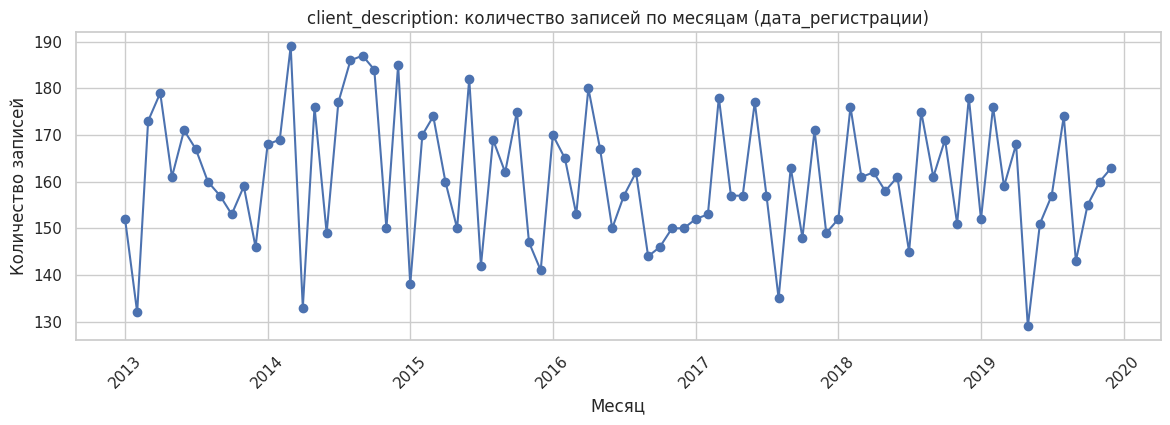

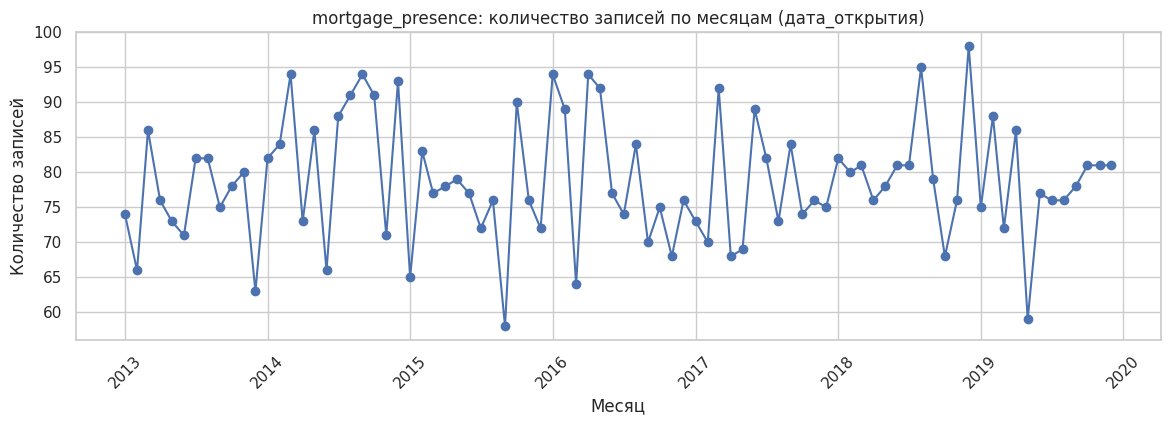

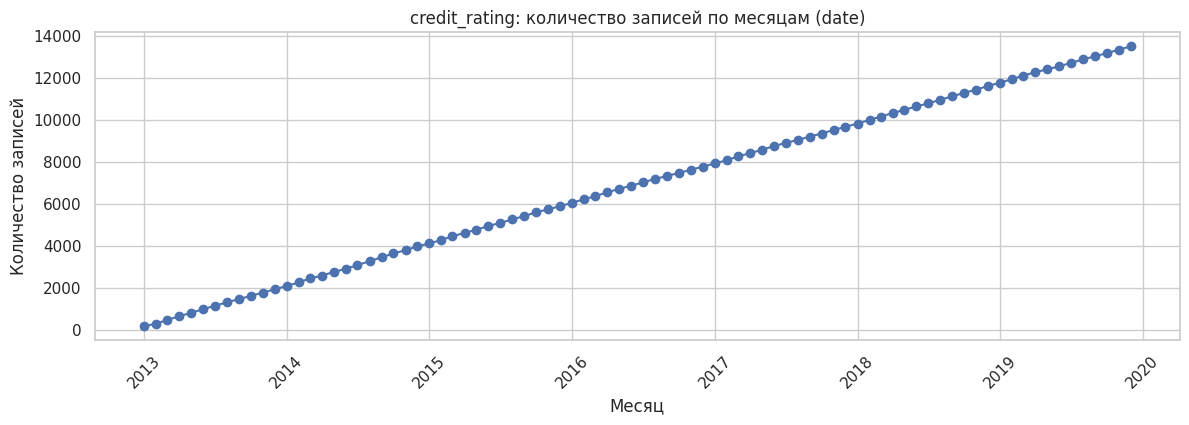

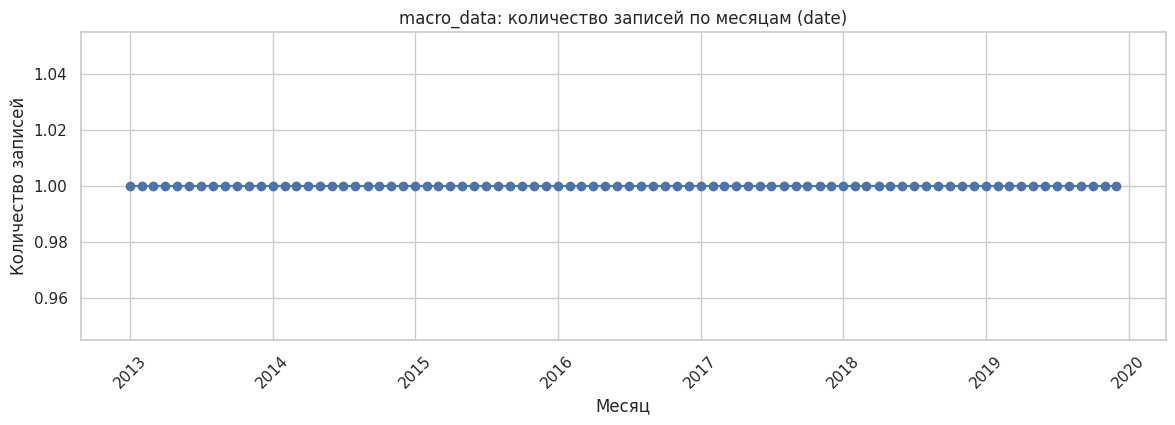

In [271]:
for name, df in df_mains.items():
    plot_date_coverage(name, df)

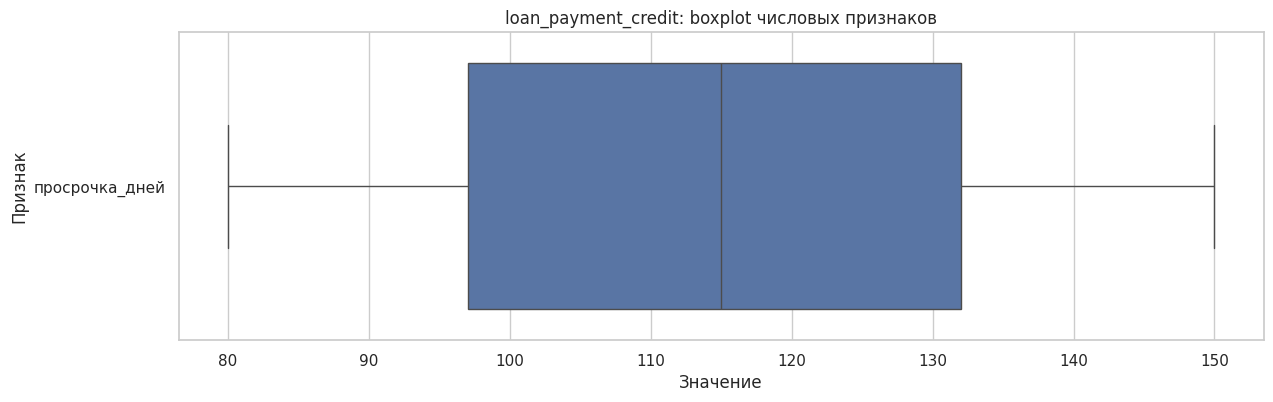

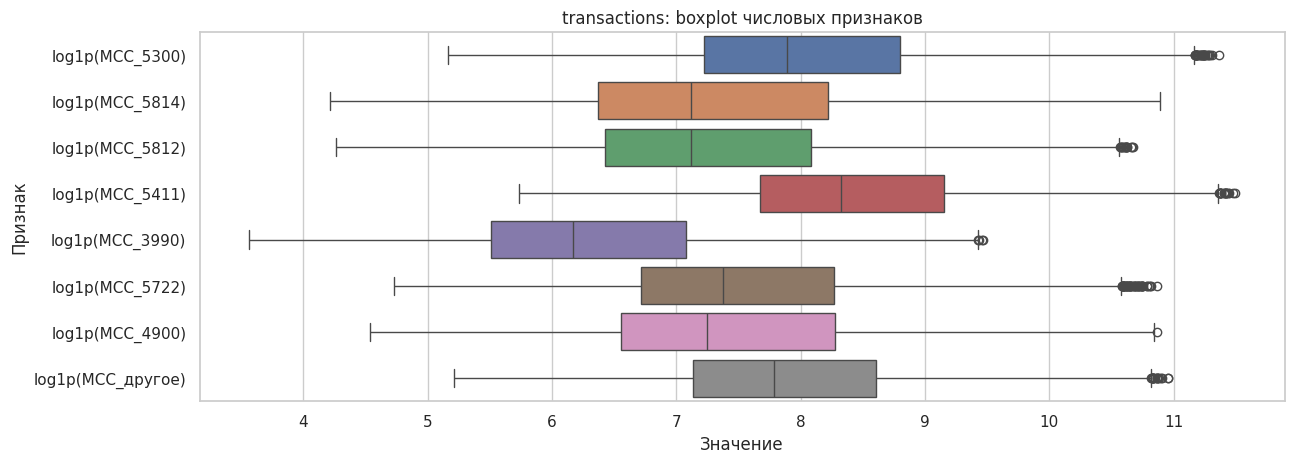

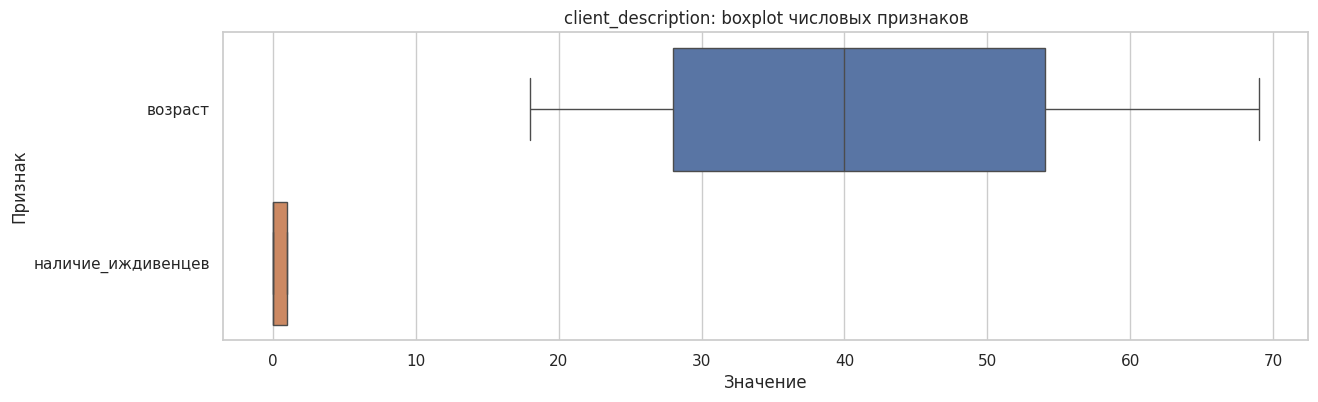

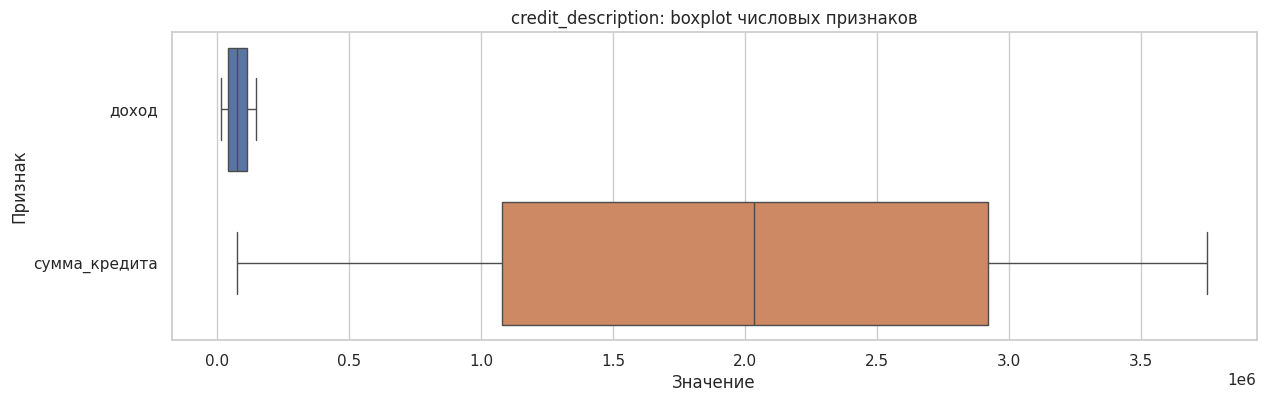

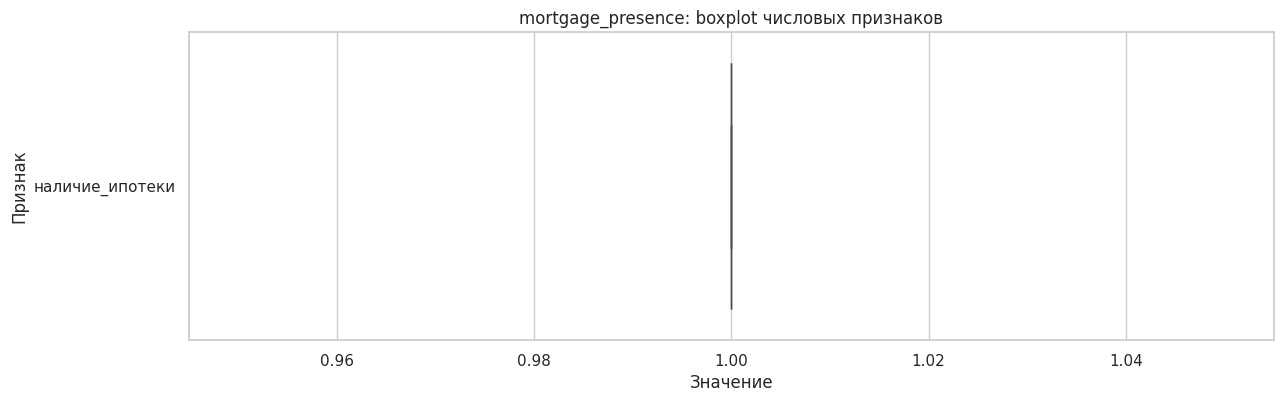

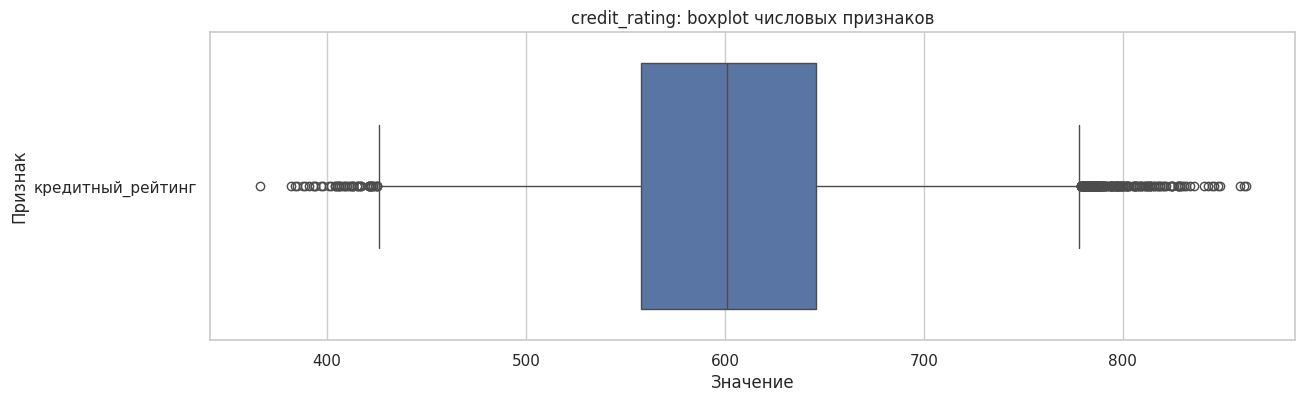

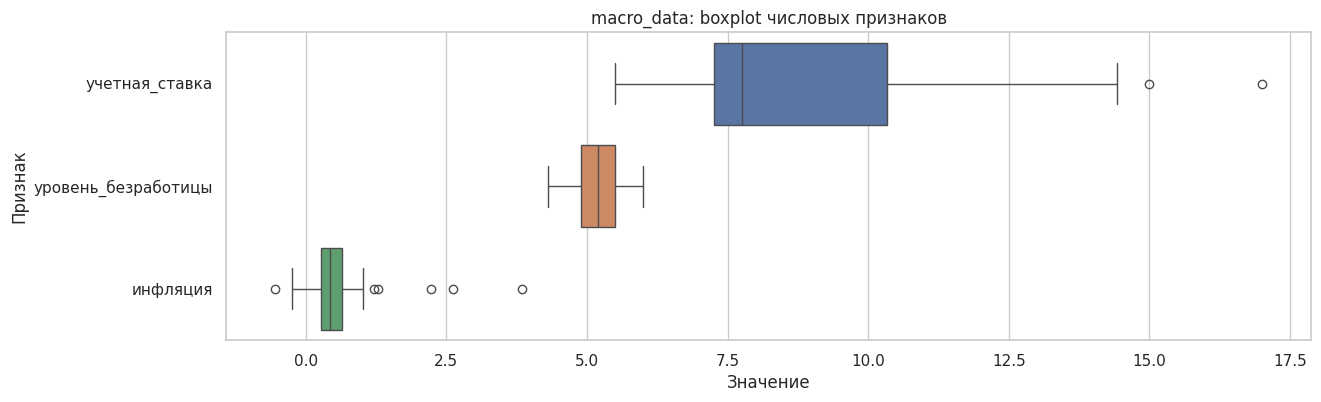

In [272]:
for name, df in df_mains.items():
    plot_numeric_boxplots(name, df)

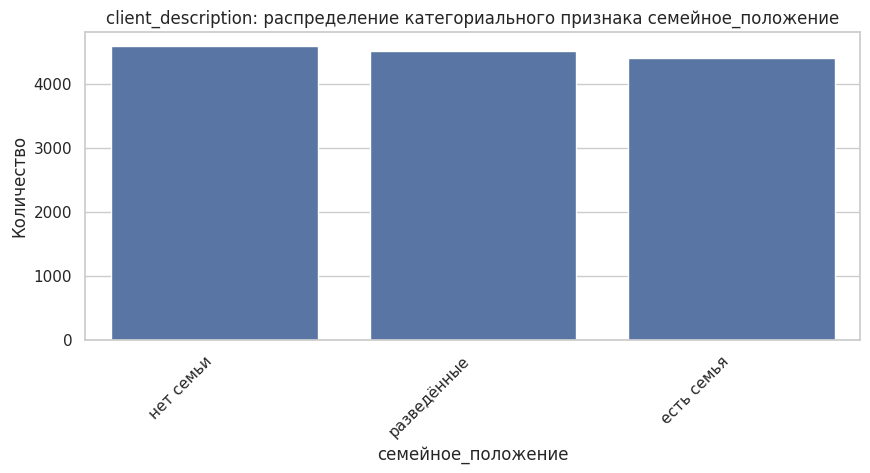

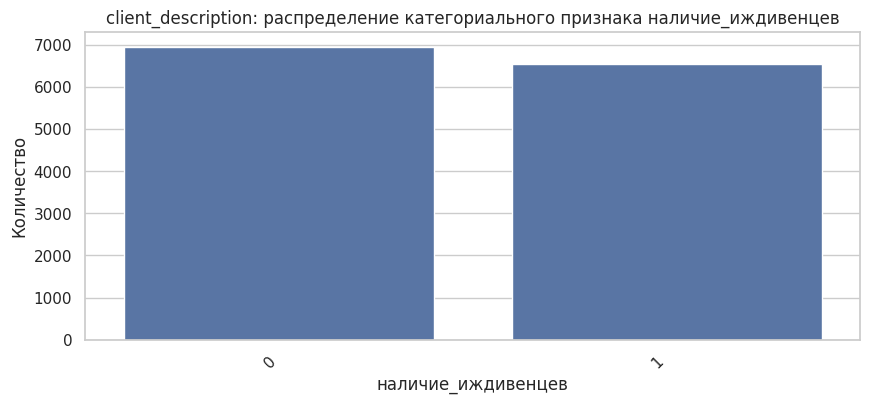

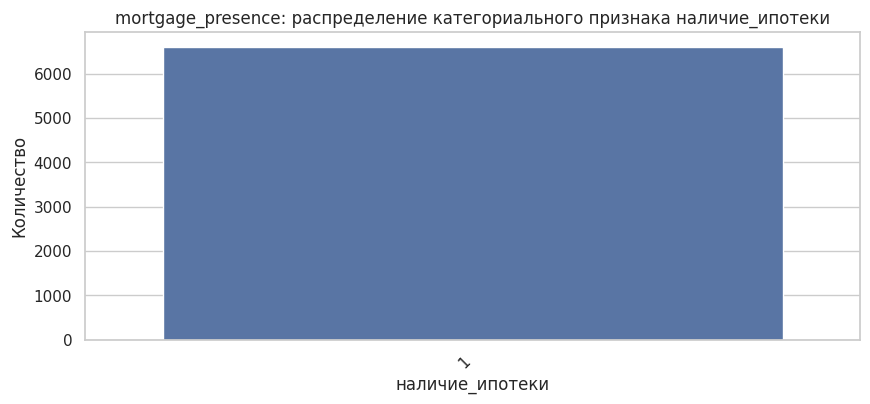

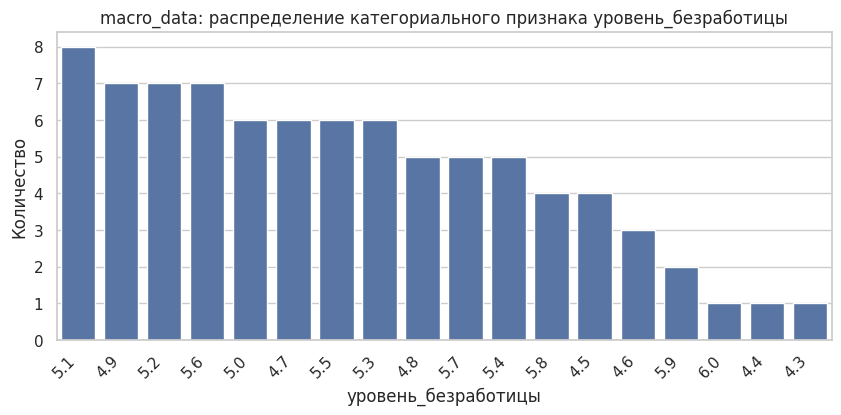

In [273]:
for name, df in df_mains.items():
    plot_categorical_distributions(name, df)

### Вывод по исследовательскому анализу данных

В ходе исследовательского анализа были изучены все исходные таблицы проекта. Для каждой таблицы были проверены размеры, типы данных, количество пропусков, явные дубликаты, число уникальных значений, диапазоны дат и распределения числовых признаков. Также были построены графики для анализа временного покрытия, количественных и категориальных признаков.

Во всех таблицах отсутствуют пропуски и явные дубликаты. Это означает, что на текущем этапе не требуется удалять строки или заполнять пропущенные значения. Однако календарные признаки после загрузки имеют тип `object`, поэтому перед объединением таблиц их необходимо привести к типу `datetime`.

Основная таблица `cohort_grid` содержит сетку наблюдений «клиент — дата скоринга». Она включает 577 494 строки и 13 500 уникальных клиентов. Даты скоринга покрывают период с января 2013 года по декабрь 2019 года. Таблицы `transactions` и `credit_rating` имеют такое же количество строк и клиентов, что говорит о согласованности этих источников с основной сеткой наблюдений.

В таблице транзакций все MCC-признаки являются числовыми. Их распределения имеют выраженную правостороннюю асимметрию: медианные значения заметно ниже максимальных. Это ожидаемо для финансовых расходов клиентов, так как отдельные клиенты могут совершать крупные траты в отдельных категориях. Такие значения не следует автоматически считать ошибками данных, но при построении модели стоит учитывать возможное влияние выбросов и создать агрегированные признаки по тратам.

Таблицы `client_description` и `credit_description` содержат по одной записи на каждого клиента. В них не выявлено дубликатов по `ID`. Возраст клиентов находится в реалистичном диапазоне от 18 до 69 лет. Признак `семейное_положение` содержит три категории, а `наличие_иждивенцев` является бинарным признаком.

Таблица `mortgage_presence` содержит только клиентов с ипотекой: признак `наличие_ипотеки` во всех строках равен 1. Поэтому отсутствие клиента в этой таблице при объединении нужно будет интерпретировать как отсутствие ипотеки. Также необходимо учитывать дату открытия ипотеки, чтобы не присвоить клиенту ипотеку раньше фактической даты её появления.

Таблица `loan_payment_credit` содержит 5 500 записей о клиентах с просрочками. Значения длительности просрочки лежат в диапазоне от 80 до 150 дней. Эта таблица является событийной и будет использоваться для формирования целевой переменной. Её нельзя напрямую присоединять как обычный признак без учёта временной логики, так как это может привести к утечке информации из будущего.

Таблица `macro_data` содержит помесячные макроэкономические показатели за тот же период, что и основная временная сетка. Её можно будет присоединить к итоговой таблице по месяцу скоринга.

В целом данные выглядят согласованными и пригодными для дальнейшей работы. Основные особенности, которые нужно учесть на следующих этапах: приведение дат к типу `datetime`, аккуратное объединение таблиц по временной логике, корректное формирование целевой переменной в горизонте 12 месяцев и недопущение утечки будущей информации в признаки.

## Объединение таблиц

Соберите все источники данных о клиентах в единую таблицу наблюдений.

### Формирование целевой переменной

1. Значение бинарной целевой переменной нужно определить для каждой строки со столбцами `ID` и `score_date` в таблице `cohort_grid`.

2. Таргет равен 1 при соблюдении двух условий:
    * Если значение в поле `просрочка_дней` больше или равно 90.
    * Если для клиента существует строка в таблице `loan_payment_credit`, где значение в поле `дата_начала_периода` попадает в интервал `[score_date, score_date + 365 дней)`.

>Важно: у клиента может быть несколько эпизодов с просрочками от 90 дней. Вам нужно взять первый по времени возникновения эпизод в таблице с просрочками.

3. После расчёта целевой переменной удалите строки, где дефолт уже произошёл к моменту скоринга, то есть `дата_начала_периода < score_date`. Это необходимо, так как для корректной работы с временной структурой важно учитывать дефолты, произошедшие в прошлом относительно даты скоринга.

### Создание итоговой таблицы

1. В качестве признаков можно использовать только информацию о прошлом, то есть она должна быть доступна к дате скоринга. Иными словами, в каждой строке нужно присоединить данные о поведении клиента за предыдущие периоды относительно даты скоринга, иначе произойдёт утечка данных из будущего.

>К примеру, `score_date = 2024-01-15`. Тогда:
>* транзакции за декабрь 2023 г. — можем использовать;
>* транзакции за ноябрь 2023 г. — можем использовать;
>* транзакции 16 января 2024 г. — **не** можем использовать.

2. Присоедините остальные данные по клиенту, помимо указанных выше данных о макроэкономике и транзакциях клиента.

> Рекомендации:
>* Не забывайте проверять правильность каждого этапа сбора данных в единую таблицу. Это можно отслеживать на одном из клиентов.
>* При формировании таблицы следите за тем, чтобы в ней была корректно проведена работа со временем:
  >   * Отследите, не упущены ли какие-то данные из прошлого;
  >   * Проконтролируйте, верно ли рассчитана целевая переменная, которая зависит от дефолта в будущем.
>* Помните, что даты в исходных таблицах указаны на первое число месяца. Учитывайте период, который они описывают.

Сделайте выводы о получившейся таблице.

In [274]:
# Приводим даты к datetime
cohort_grid[SCORE_DATE_COL] = pd.to_datetime(
    cohort_grid[SCORE_DATE_COL],
    errors="coerce"
)

loan_payment_credit[DEFAULT_START_COL] = pd.to_datetime(
    loan_payment_credit[DEFAULT_START_COL],
    errors="coerce"
)

# Проверим, что даты распарсились корректно
print("Пропуски в score_date после преобразования:")
print(cohort_grid[SCORE_DATE_COL].isna().sum())

print("\nПропуски в дате начала периода просрочки после преобразования:")
print(loan_payment_credit[DEFAULT_START_COL].isna().sum())

Пропуски в score_date после преобразования:
0

Пропуски в дате начала периода просрочки после преобразования:
0


In [275]:
# Отбираем только дефолтные эпизоды: просрочка 90+ дней
default_events = loan_payment_credit[
    loan_payment_credit[DEFAULT_DAYS_COL] >= DEFAULT_DAYS_THRESHOLD
].copy()

# Если у клиента несколько дефолтных эпизодов, берём первый по времени
first_default_events = (
    default_events
    .sort_values([ID_COL, DEFAULT_START_COL])
    .groupby(ID_COL, as_index=False)
    .first()
    .rename(
        columns={
            DEFAULT_START_COL: "first_default_90plus_date",
            DEFAULT_DAYS_COL: "first_default_90plus_days",
        }
    )
)

print(f"Всего записей в таблице просрочек: {len(loan_payment_credit)}")
print(f"Эпизодов с просрочкой 90+ дней: {len(default_events)}")
print(f"Клиентов с хотя бы одним эпизодом 90+ дней: {first_default_events[ID_COL].nunique()}")

display(first_default_events.head())

Всего записей в таблице просрочек: 5500
Эпизодов с просрочкой 90+ дней: 4712
Клиентов с хотя бы одним эпизодом 90+ дней: 4712


,ID,first_default_90plus_date,first_default_90plus_days
0,IDF54896351,2014-10-01,93
1,IDF54896494,2019-07-01,137
2,IDF54896677,2017-09-01,90
3,IDF54896685,2017-11-01,136
4,IDF54896744,2019-02-01,97


In [276]:
# Базовая таблица наблюдений: каждая строка — клиент на дату скоринга
df_target_base = cohort_grid.merge(
    first_default_events[
        [ID_COL, "first_default_90plus_date", "first_default_90plus_days"]
    ],
    on=ID_COL,
    how="left"
)

# Конец горизонта прогнозирования: [score_date, score_date + 365 дней)
df_target_base["forecast_end_date"] = (
    df_target_base[SCORE_DATE_COL] + pd.Timedelta(days=HORIZON_DAYS)
)

# Сколько дней осталось до первого дефолта 90+
df_target_base["days_to_first_default"] = (
    df_target_base["first_default_90plus_date"] - df_target_base[SCORE_DATE_COL]
).dt.days

# Таргет равен 1, если первый дефолт 90+ попадает в горизонт [score_date, score_date + 365 дней)
df_target_base[TARGET] = (
    df_target_base["first_default_90plus_date"].notna()
    & (df_target_base["first_default_90plus_date"] >= df_target_base[SCORE_DATE_COL])
    & (df_target_base["first_default_90plus_date"] < df_target_base["forecast_end_date"])
).astype(int)

display(df_target_base.head())

,ID,score_date,first_default_90plus_date,first_default_90plus_days,forecast_end_date,days_to_first_default,target
0,IDF55109846,2013-05-01,2014-12-01,120.000,2014-05-01,579.000,0
1,IDF55109846,2013-06-01,2014-12-01,120.000,2014-06-01,548.000,0
2,IDF55109846,2013-07-01,2014-12-01,120.000,2014-07-01,518.000,0
3,IDF55109846,2013-08-01,2014-12-01,120.000,2014-08-01,487.000,0
4,IDF55109846,2013-09-01,2014-12-01,120.000,2014-09-01,456.000,0


In [277]:
# Строки, где первый дефолт уже случился к моменту скоринга
past_default_mask = (
    df_target_base["first_default_90plus_date"].notna()
    & (df_target_base["first_default_90plus_date"] < df_target_base[SCORE_DATE_COL])
)

print(f"Размер до удаления строк с уже произошедшим дефолтом: {df_target_base.shape}")
print(f"Строк к удалению: {past_default_mask.sum()}")

# Удаляем такие строки
df_observations = df_target_base.loc[~past_default_mask].copy()

print(f"Размер после удаления строк с уже произошедшим дефолтом: {df_observations.shape}")
print(f"Удалено строк: {df_target_base.shape[0] - df_observations.shape[0]}")

Размер до удаления строк с уже произошедшим дефолтом: (577494, 7)
Строк к удалению: 139115
Размер после удаления строк с уже произошедшим дефолтом: (438379, 7)
Удалено строк: 139115


In [278]:
# Проверка: нет ли дубликатов по паре ID + score_date
duplicated_pairs = df_observations.duplicated([ID_COL, SCORE_DATE_COL]).sum()
print(f"Дубликатов по паре ID + score_date: {duplicated_pairs}")

# Проверка: после фильтрации не должно остаться строк, где дефолт уже был в прошлом
past_defaults_left = (
    df_observations["first_default_90plus_date"].notna()
    & (df_observations["first_default_90plus_date"] < df_observations[SCORE_DATE_COL])
).sum()

print(f"Строк с дефолтом в прошлом после фильтрации: {past_defaults_left}")

# Проверка значений таргета
print("\nРаспределение целевой переменной:")
target_distribution = (
    df_observations[TARGET]
    .value_counts(dropna=False)
    .rename("count")
    .to_frame()
)

target_distribution["percent"] = (
    target_distribution["count"] / len(df_observations) * 100
).round(2)

display(target_distribution)

# Контрольные assert
assert duplicated_pairs == 0
assert past_defaults_left == 0
assert df_observations[TARGET].isin([0, 1]).all()

Дубликатов по паре ID + score_date: 0
Строк с дефолтом в прошлом после фильтрации: 0

Распределение целевой переменной:


,count,percent
target,,
0,389015,88.740
1,49364,11.260


,score_date,observations,target_1_count,target_1_share
0,2013-01-01,152,10,0.066
1,2013-02-01,284,24,0.085
2,2013-03-01,457,48,0.105
3,2013-04-01,636,71,0.112
4,2013-05-01,797,98,0.123


,score_date,observations,target_1_count,target_1_share
79,2019-08-01,8714,333,0.038
80,2019-09-01,8737,266,0.030
81,2019-10-01,8790,225,0.026
82,2019-11-01,8839,160,0.018
83,2019-12-01,8888,100,0.011


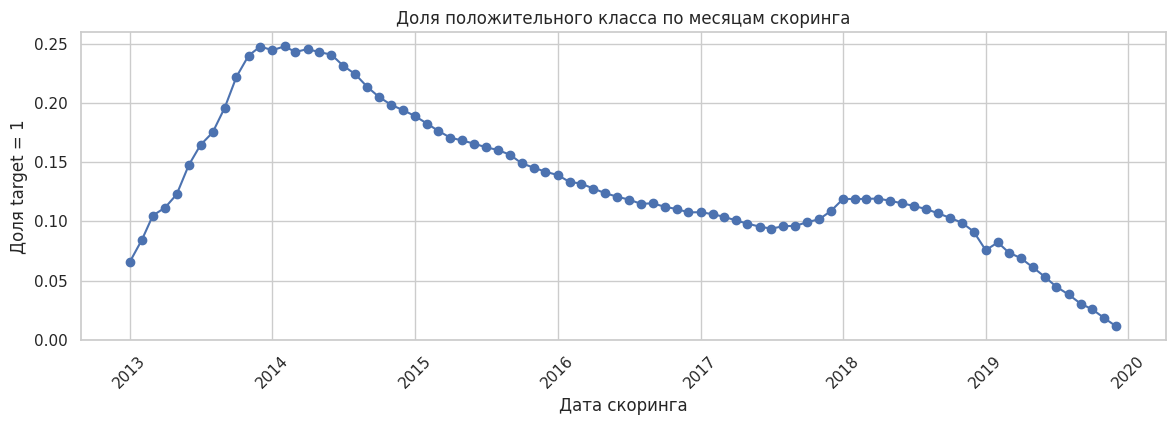

In [279]:
target_by_month = (
    df_observations
    .groupby(SCORE_DATE_COL)[TARGET]
    .agg(["count", "sum", "mean"])
    .rename(
        columns={
            "count": "observations",
            "sum": "target_1_count",
            "mean": "target_1_share",
        }
    )
    .reset_index()
)

display(target_by_month.head())
display(target_by_month.tail())

plt.figure(figsize=(14, 4))
plt.plot(
    target_by_month[SCORE_DATE_COL],
    target_by_month["target_1_share"],
    marker="o"
)
plt.title("Доля положительного класса по месяцам скоринга")
plt.xlabel("Дата скоринга")
plt.ylabel("Доля target = 1")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Промежуточный вывод по формированию целевой переменной

На этом этапе была сформирована бинарная целевая переменная `target` для каждой строки из таблицы `cohort_grid`, то есть для каждой пары «клиент — дата скоринга». Перед расчётом таргета даты в таблицах `cohort_grid` и `loan_payment_credit` были приведены к типу `datetime`. Ошибок преобразования дат не обнаружено: пропуски после преобразования отсутствуют.

В таблице просрочек содержится 5 500 записей. Из них 4 712 эпизодов соответствуют условию дефолта, то есть имеют длительность просрочки 90 дней и более. Для каждого клиента был выбран первый по времени эпизод просрочки 90+ дней, так как именно он используется для корректного определения будущего дефолта относительно даты скоринга.

Для каждой строки из `cohort_grid` был рассчитан горизонт прогнозирования: интервал от `score_date` до `score_date + 365 дней`. Целевая переменная получила значение `1`, если первый дефолт клиента попадал в этот интервал, и `0` — если дефолт не попадал в горизонт прогнозирования или у клиента не было дефолта 90+ дней.

После расчёта таргета были удалены строки, в которых дефолт уже произошёл до даты скоринга. Это необходимо, потому что такие наблюдения не соответствуют задаче прогнозирования будущего риска: на момент скоринга дефолт уже известен. До удаления таблица содержала 577 494 строки, после удаления осталось 438 379 строк. Было удалено 139 115 строк с уже произошедшим дефолтом.

Дополнительные проверки показали, что в итоговой таблице наблюдений нет дубликатов по паре `ID` и `score_date`, а также не осталось строк, где дата первого дефолта находится в прошлом относительно даты скоринга. Это подтверждает корректность временной фильтрации.

Распределение целевой переменной показывает дисбаланс классов: положительный класс `target = 1` составляет 49 364 наблюдения, или 11.26% выборки, отрицательный класс `target = 0` — 389 015 наблюдений, или 88.74%. Следовательно, задача является несбалансированной бинарной классификацией. На этапе моделирования потребуется учитывать дисбаланс классов с помощью специальных методов балансировки или весов классов.

Также видно, что доля положительного класса меняется во времени: в начале периода она постепенно растёт, а к концу 2019 года заметно снижается. Это ожидаемо, так как для последних месяцев наблюдений горизонт будущего дефолта ограничен доступными данными. При дальнейшем разбиении выборки и кросс-валидации необходимо учитывать временную структуру данных.

In [280]:
# Копируем базовую таблицу наблюдений с уже рассчитанным target
df_final = df_observations.copy()

print(f"Стартовый размер df_final: {df_final.shape}")
display(df_final.head())

Стартовый размер df_final: (438379, 7)


,ID,score_date,first_default_90plus_date,first_default_90plus_days,forecast_end_date,days_to_first_default,target
0,IDF55109846,2013-05-01,2014-12-01,120.000,2014-05-01,579.000,0
1,IDF55109846,2013-06-01,2014-12-01,120.000,2014-06-01,548.000,0
2,IDF55109846,2013-07-01,2014-12-01,120.000,2014-07-01,518.000,0
3,IDF55109846,2013-08-01,2014-12-01,120.000,2014-08-01,487.000,0
4,IDF55109846,2013-09-01,2014-12-01,120.000,2014-09-01,456.000,0


In [281]:
# Приводим даты к datetime
df_final[SCORE_DATE_COL] = pd.to_datetime(df_final[SCORE_DATE_COL], errors="coerce")

client_description["дата_регистрации"] = pd.to_datetime(
    client_description["дата_регистрации"],
    errors="coerce"
)

mortgage_presence["дата_открытия"] = pd.to_datetime(
    mortgage_presence["дата_открытия"],
    errors="coerce"
)

credit_rating["date"] = pd.to_datetime(
    credit_rating["date"],
    errors="coerce"
)

transactions["date"] = pd.to_datetime(
    transactions["date"],
    errors="coerce"
)

macro_data["date"] = pd.to_datetime(
    macro_data["date"],
    errors="coerce"
)

In [282]:
# Функция для контроля после каждого объединения

def check_merge_result(df_before, df_after, step_name):
    print("=" * 80)
    print(step_name)
    print("=" * 80)

    print(f"Размер до объединения: {df_before.shape}")
    print(f"Размер после объединения: {df_after.shape}")

    row_diff = df_after.shape[0] - df_before.shape[0]
    print(f"Изменение количества строк: {row_diff}")

    duplicated_pairs = df_after.duplicated([ID_COL, SCORE_DATE_COL]).sum()
    print(f"Дубликатов по паре ID + score_date: {duplicated_pairs}")

    if row_diff != 0:
        print("Внимание: количество строк изменилось.")

    if duplicated_pairs != 0:
        print("Внимание: появились дубликаты по ID + score_date.")

    print("\n")

In [283]:
df_before = df_final.copy()

df_final = df_final.merge(
    client_description,
    on=ID_COL,
    how="left",
    validate="many_to_one"
)

check_merge_result(df_before, df_final, "Присоединение client_description")

Присоединение client_description
Размер до объединения: (438379, 7)
Размер после объединения: (438379, 11)
Изменение количества строк: 0
Дубликатов по паре ID + score_date: 0




In [284]:
df_before = df_final.copy()

df_final = df_final.merge(
    credit_description,
    on=ID_COL,
    how="left",
    validate="many_to_one"
)

check_merge_result(df_before, df_final, "Присоединение credit_description")

Присоединение credit_description
Размер до объединения: (438379, 11)
Размер после объединения: (438379, 13)
Изменение количества строк: 0
Дубликатов по паре ID + score_date: 0




In [285]:
df_before = df_final.copy()

mortgage_features = mortgage_presence[
    [ID_COL, "дата_открытия", "наличие_ипотеки"]
].copy()

df_final = df_final.merge(
    mortgage_features,
    on=ID_COL,
    how="left",
    validate="many_to_one"
)

# Если клиента нет в таблице mortgage_presence, считаем, что ипотеки нет.
# Если ипотека открыта после score_date, на момент скоринга её ещё нельзя учитывать.
df_final["наличие_ипотеки"] = (
    df_final["дата_открытия"].notna()
    & (df_final["дата_открытия"] <= df_final[SCORE_DATE_COL])
).astype(int)

# Дату открытия оставляем как исходную информацию.
check_merge_result(df_before, df_final, "Присоединение mortgage_presence")

Присоединение mortgage_presence
Размер до объединения: (438379, 13)
Размер после объединения: (438379, 15)
Изменение количества строк: 0
Дубликатов по паре ID + score_date: 0




In [286]:
df_before = df_final.copy()

credit_rating_for_merge = credit_rating.rename(
    columns={"date": SCORE_DATE_COL}
)

df_final = df_final.merge(
    credit_rating_for_merge,
    on=[ID_COL, SCORE_DATE_COL],
    how="left",
    validate="many_to_one"
)

check_merge_result(df_before, df_final, "Присоединение credit_rating")

Присоединение credit_rating
Размер до объединения: (438379, 15)
Размер после объединения: (438379, 16)
Изменение количества строк: 0
Дубликатов по паре ID + score_date: 0




In [287]:
df_before = df_final.copy()

transactions_for_merge = transactions.copy()

# Транзакции за месяц date используем для следующего месяца скоринга
transactions_for_merge[SCORE_DATE_COL] = (
    transactions_for_merge["date"] + pd.DateOffset(months=1)
)

transactions_for_merge = transactions_for_merge.drop(columns=["date"])

# Чтобы было явно понятно, что это данные прошлого месяца
mcc_columns = [
    col for col in transactions_for_merge.columns
    if col.startswith("MCC_")
]

transactions_for_merge = transactions_for_merge.rename(
    columns={col: f"{col}_prev_month" for col in mcc_columns}
)

df_final = df_final.merge(
    transactions_for_merge,
    on=[ID_COL, SCORE_DATE_COL],
    how="left",
    validate="many_to_one"
)

check_merge_result(df_before, df_final, "Присоединение transactions за предыдущий месяц")

Присоединение transactions за предыдущий месяц
Размер до объединения: (438379, 16)
Размер после объединения: (438379, 24)
Изменение количества строк: 0
Дубликатов по паре ID + score_date: 0




In [288]:
df_before = df_final.copy()

macro_for_merge = macro_data.copy()

macro_for_merge[SCORE_DATE_COL] = (
    macro_for_merge["date"] + pd.DateOffset(months=1)
)

macro_for_merge = macro_for_merge.drop(columns=["date"])

macro_columns = [
    "учетная_ставка",
    "уровень_безработицы",
    "инфляция",
]

macro_for_merge = macro_for_merge.rename(
    columns={col: f"{col}_prev_month" for col in macro_columns}
)

df_final = df_final.merge(
    macro_for_merge,
    on=SCORE_DATE_COL,
    how="left",
    validate="many_to_one"
)

check_merge_result(df_before, df_final, "Присоединение macro_data за предыдущий месяц")

Присоединение macro_data за предыдущий месяц
Размер до объединения: (438379, 24)
Размер после объединения: (438379, 27)
Изменение количества строк: 0
Дубликатов по паре ID + score_date: 0




In [289]:
# Удаляем служебные колонки с утечкой

leakage_columns = [
    "first_default_90plus_date",
    "first_default_90plus_days",
    "forecast_end_date",
    "days_to_first_default",
]

df_model = df_final.drop(columns=leakage_columns)

print(f"Размер таблицы до удаления служебных колонок: {df_final.shape}")
print(f"Размер итоговой таблицы для дальнейшей работы: {df_model.shape}")

display(df_model.head())

Размер таблицы до удаления служебных колонок: (438379, 27)
Размер итоговой таблицы для дальнейшей работы: (438379, 23)


,ID,score_date,target,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации,доход,сумма_кредита,дата_открытия,наличие_ипотеки,кредитный_рейтинг,MCC_5300_prev_month,MCC_5814_prev_month,MCC_5812_prev_month,MCC_5411_prev_month,MCC_3990_prev_month,MCC_5722_prev_month,MCC_4900_prev_month,MCC_другое_prev_month,учетная_ставка_prev_month,уровень_безработицы_prev_month,инфляция_prev_month
0,IDF55109846,2013-05-01,0,41,разведённые,1,2013-05-01,27035,1960785,NaT,0,692,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.500,5.500,0.510
1,IDF55109846,2013-06-01,0,41,разведённые,1,2013-05-01,27035,1960785,NaT,0,688,3267.590,1282.110,1457.960,5711.100,647.430,2374.780,4059.860,3657.350,5.500,5.400,0.660
2,IDF55109846,2013-07-01,0,41,разведённые,1,2013-05-01,27035,1960785,NaT,0,666,3196.580,2443.370,1334.200,5824.650,1067.550,2187.110,4592.260,3322.610,5.500,5.300,0.420
3,IDF55109846,2013-08-01,0,41,разведённые,1,2013-05-01,27035,1960785,NaT,0,692,3550.540,4277.720,1463.750,5209.510,1167.950,2076.540,3605.250,3467.060,5.500,5.300,0.820
4,IDF55109846,2013-09-01,0,41,разведённые,1,2013-05-01,27035,1960785,NaT,0,688,3385.980,4530.630,1261.400,5765.960,986.990,2231.770,2209.390,3354.440,5.500,5.200,0.140


In [290]:
# Удаляем колонку "дата открытия", чтобы не было утечки

df_model = df_model.drop(columns=["дата_открытия"])

In [291]:
# Итоговая проверка

df_model.info()

print("\nДубликаты по ID + score_date:")
print(df_model.duplicated([ID_COL, SCORE_DATE_COL]).sum())

print("\nРаспределение target:")
target_info = (
    df_model[TARGET]
    .value_counts()
    .to_frame("count")
)

target_info["percent"] = (
    target_info["count"] / len(df_model) * 100
).round(2)

display(target_info)

print("\nПропуски в итоговой таблице:")
missing_final = df_model.isna().sum().to_frame("missing_values")
missing_final["missing_percent"] = (
    missing_final["missing_values"] / len(df_model) * 100
).round(2)

display(
    missing_final
    .query("missing_values > 0")
    .sort_values("missing_percent", ascending=False)
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438379 entries, 0 to 438378
Data columns (total 22 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   ID                              438379 non-null  object        
 1   score_date                      438379 non-null  datetime64[ns]
 2   target                          438379 non-null  int64         
 3   возраст                         438379 non-null  int64         
 4   семейное_положение              438379 non-null  object        
 5   наличие_иждивенцев              438379 non-null  int64         
 6   дата_регистрации                438379 non-null  datetime64[ns]
 7   доход                           438379 non-null  int64         
 8   сумма_кредита                   438379 non-null  int64         
 9   наличие_ипотеки                 438379 non-null  int64         
 10  кредитный_рейтинг               438379 non-null  int64  

,count,percent
target,,
0,389015,88.740
1,49364,11.260



Пропуски в итоговой таблице:


,missing_values,missing_percent
MCC_5300_prev_month,13500,3.080
MCC_5814_prev_month,13500,3.080
MCC_5812_prev_month,13500,3.080
MCC_5411_prev_month,13500,3.080
MCC_3990_prev_month,13500,3.080
MCC_5722_prev_month,13500,3.080
MCC_4900_prev_month,13500,3.080
MCC_другое_prev_month,13500,3.080
учетная_ставка_prev_month,152,0.030
уровень_безработицы_prev_month,152,0.030


### Вывод по объединению таблиц

На этапе объединения была сформирована итоговая таблица наблюдений `df_model`. В качестве базовой таблицы использовалась `cohort_grid` с уже рассчитанной целевой переменной `target`. После удаления строк, где дефолт уже произошёл до даты скоринга, в таблице осталось 438 379 наблюдений.

К итоговой таблице были последовательно присоединены данные о клиенте, параметры кредита, информация об ипотеке, кредитный рейтинг, транзакции за предыдущий месяц и макроэкономические показатели за предыдущий месяц. При объединении учитывалась временная структура данных: в признаки включалась только информация, доступная на момент скоринга или ранее. Для транзакций и макроэкономических данных использовались значения предыдущего месяца, чтобы не допустить утечки информации из будущего.

После объединения итоговая таблица содержит 22 столбца. Дубликатов по паре `ID` и `score_date` не обнаружено, следовательно, единица наблюдения сохранена корректно: одна строка соответствует одному клиенту на одну дату скоринга. Распределение целевой переменной также не изменилось: отрицательный класс составляет 88.74%, положительный класс — 11.26%.

В итоговой таблице остались пропуски в признаках транзакций за предыдущий месяц: по 13 500 пропусков в каждом MCC-признаке, что составляет 3.08% данных. Это ожидаемо, так как для первых наблюдений клиентов отсутствует информация за предыдущий месяц. Также есть 152 пропуска в макроэкономических признаках предыдущего месяца, что связано с отсутствием предыдущего периода для самых ранних дат скоринга. Эти пропуски не являются ошибками данных и будут обработаны позже на этапе подготовки признаков к моделированию.

Информация об ипотеке была присоединена с учётом даты скоринга: если ипотека была открыта позже даты скоринга или клиент отсутствовал в таблице ипотек, признак `наличие_ипотеки` принимал значение 0. Дата открытия ипотеки не была оставлена в модельной таблице, чтобы избежать возможной утечки будущей информации.

Таким образом, итоговая таблица собрана корректно: строки не потеряны и не размножены, целевая переменная сохранена, временная логика при присоединении данных соблюдена. Полученная таблица может использоваться для дальнейшего создания новых признаков и подготовки данных к моделированию.

## Создание новых признаков

* Добавьте в таблицу новые признаки, которые помогли бы описать поведение клиента. Создайте не менее двух новых признаков.
* Сделайте выводы о новых признаках.

In [292]:
df_features = df_model.copy()

print(f"Размер таблицы до создания новых признаков: {df_features.shape}")

Размер таблицы до создания новых признаков: (438379, 22)


In [293]:
new_feature_columns = []

# Стаж клиента в банке на дату скоринга, в месяцах
df_features["client_tenure_months"] = (
    (df_features[SCORE_DATE_COL].dt.year - df_features["дата_регистрации"].dt.year) * 12
    + (df_features[SCORE_DATE_COL].dt.month - df_features["дата_регистрации"].dt.month)
)

new_feature_columns.append("client_tenure_months")

# Отношение суммы кредита к месячному доходу
df_features["credit_to_income_ratio"] = (
    df_features["сумма_кредита"] / df_features["доход"]
)

new_feature_columns.append("credit_to_income_ratio")

# Отношение суммы кредита к годовому доходу
df_features["credit_to_annual_income_ratio"] = (
    df_features["сумма_кредита"] / (df_features["доход"] * 12)
)

new_feature_columns.append("credit_to_annual_income_ratio")

# Семейная финансовая нагрузка: есть семья и есть иждивенцы
df_features["family_with_dependents"] = (
    (df_features["семейное_положение"] == "есть семья")
    & (df_features["наличие_иждивенцев"] == 1)
).astype(int)

new_feature_columns.append("family_with_dependents")

print("Созданы признаки клиентского стажа и кредитной нагрузки:")
print(new_feature_columns)

Созданы признаки клиентского стажа и кредитной нагрузки:
['client_tenure_months', 'credit_to_income_ratio', 'credit_to_annual_income_ratio', 'family_with_dependents']


In [294]:
mcc_prev_columns = [
    col for col in df_features.columns
    if col.startswith("MCC_") and col.endswith("_prev_month")
]

# Общие траты за предыдущий месяц
df_features["total_spend_prev_month"] = (
    df_features[mcc_prev_columns].sum(axis=1, min_count=1)
)

new_feature_columns.append("total_spend_prev_month")

# Траты на еду: супермаркеты + фастфуд + рестораны
food_columns = [
    "MCC_5411_prev_month",
    "MCC_5814_prev_month",
    "MCC_5812_prev_month",
]

df_features["food_spend_prev_month"] = (
    df_features[food_columns].sum(axis=1, min_count=1)
)

new_feature_columns.append("food_spend_prev_month")

# Обязательные/регулярные траты: продукты + ЖКУ
essential_columns = [
    "MCC_5411_prev_month",
    "MCC_4900_prev_month",
]

df_features["essential_spend_prev_month"] = (
    df_features[essential_columns].sum(axis=1, min_count=1)
)

new_feature_columns.append("essential_spend_prev_month")

# Условно необязательные траты
discretionary_columns = [
    "MCC_5300_prev_month",
    "MCC_5814_prev_month",
    "MCC_5812_prev_month",
    "MCC_3990_prev_month",
    "MCC_5722_prev_month",
    "MCC_другое_prev_month",
]

df_features["discretionary_spend_prev_month"] = (
    df_features[discretionary_columns].sum(axis=1, min_count=1)
)

new_feature_columns.append("discretionary_spend_prev_month")

# Доля трат на еду
df_features["food_spend_share_prev_month"] = (
    df_features["food_spend_prev_month"] / df_features["total_spend_prev_month"]
)

new_feature_columns.append("food_spend_share_prev_month")

# Доля обязательных трат
df_features["essential_spend_share_prev_month"] = (
    df_features["essential_spend_prev_month"] / df_features["total_spend_prev_month"]
)

new_feature_columns.append("essential_spend_share_prev_month")

# Соотношение необязательных и обязательных трат
df_features["discretionary_to_essential_ratio_prev_month"] = (
    df_features["discretionary_spend_prev_month"] / df_features["essential_spend_prev_month"]
)

new_feature_columns.append("discretionary_to_essential_ratio_prev_month")

for col in mcc_prev_columns:
    share_col = col.replace("_prev_month", "_share_prev_month")
    
    df_features[share_col] = (
        df_features[col] / df_features["total_spend_prev_month"]
    )
    
    new_feature_columns.append(share_col)

In [295]:
# Rolling-признаки по транзакциям за прошлые месяцы

transactions_features = dataframes["transactions"].copy()

transactions_features["date"] = pd.to_datetime(
    transactions_features["date"],
    errors="coerce"
)

mcc_columns = [
    col for col in transactions_features.columns
    if col.startswith("MCC_")
]

transactions_features = transactions_features.sort_values([ID_COL, "date"])

transactions_features["total_spend"] = (
    transactions_features[mcc_columns].sum(axis=1)
)

# Средние траты за последние 3 месяца до скоринга
transactions_features["total_spend_roll_3m_mean"] = (
    transactions_features
    .groupby(ID_COL)["total_spend"]
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

# Средние траты за последние 6 месяцев до скоринга
transactions_features["total_spend_roll_6m_mean"] = (
    transactions_features
    .groupby(ID_COL)["total_spend"]
    .transform(lambda x: x.rolling(window=6, min_periods=1).mean())
)

# Стандартное отклонение трат за последние 3 месяца
transactions_features["total_spend_roll_3m_std"] = (
    transactions_features
    .groupby(ID_COL)["total_spend"]
    .transform(lambda x: x.rolling(window=3, min_periods=2).std())
)

# Динамика: насколько траты прошлого месяца отличаются от среднего за последние 3 месяца
transactions_features["total_spend_vs_3m_mean_ratio"] = (
    transactions_features["total_spend"]
    / transactions_features["total_spend_roll_3m_mean"]
)

# Месяц транзакций используем для следующего месяца скоринга
transactions_features[SCORE_DATE_COL] = (
    transactions_features["date"] + pd.DateOffset(months=1)
)

transaction_rolling_columns = [
    "total_spend_roll_3m_mean",
    "total_spend_roll_6m_mean",
    "total_spend_roll_3m_std",
    "total_spend_vs_3m_mean_ratio",
]

transactions_features_for_merge = transactions_features[
    [ID_COL, SCORE_DATE_COL] + transaction_rolling_columns
].copy()

df_before_shape = df_features.shape

df_features = df_features.merge(
    transactions_features_for_merge,
    on=[ID_COL, SCORE_DATE_COL],
    how="left",
    validate="many_to_one"
)

print(f"Размер до присоединения rolling-признаков транзакций: {df_before_shape}")
print(f"Размер после присоединения rolling-признаков транзакций: {df_features.shape}")
print(f"Дубликаты по ID + score_date: {df_features.duplicated([ID_COL, SCORE_DATE_COL]).sum()}")

new_feature_columns.extend(transaction_rolling_columns)

Размер до присоединения rolling-признаков транзакций: (438379, 41)
Размер после присоединения rolling-признаков транзакций: (438379, 45)
Дубликаты по ID + score_date: 0


In [296]:
# Признаки динамики кредитного рейтинга

rating_features = dataframes["credit_rating"].copy()

rating_features["date"] = pd.to_datetime(
    rating_features["date"],
    errors="coerce"
)

rating_features = rating_features.sort_values([ID_COL, "date"])

rating_features["credit_rating_prev_1m"] = (
    rating_features
    .groupby(ID_COL)["кредитный_рейтинг"]
    .shift(1)
)

rating_features["credit_rating_change_1m"] = (
    rating_features["кредитный_рейтинг"]
    - rating_features["credit_rating_prev_1m"]
)

rating_features["credit_rating_roll_3m_mean"] = (
    rating_features
    .groupby(ID_COL)["кредитный_рейтинг"]
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

rating_features["credit_rating_vs_3m_mean"] = (
    rating_features["кредитный_рейтинг"]
    - rating_features["credit_rating_roll_3m_mean"]
)

rating_features = rating_features.rename(
    columns={"date": SCORE_DATE_COL}
)

rating_feature_columns = [
    "credit_rating_prev_1m",
    "credit_rating_change_1m",
    "credit_rating_roll_3m_mean",
    "credit_rating_vs_3m_mean",
]

rating_features_for_merge = rating_features[
    [ID_COL, SCORE_DATE_COL] + rating_feature_columns
].copy()

df_before_shape = df_features.shape

df_features = df_features.merge(
    rating_features_for_merge,
    on=[ID_COL, SCORE_DATE_COL],
    how="left",
    validate="many_to_one"
)

print(f"Размер до присоединения признаков рейтинга: {df_before_shape}")
print(f"Размер после присоединения признаков рейтинга: {df_features.shape}")
print(f"Дубликаты по ID + score_date: {df_features.duplicated([ID_COL, SCORE_DATE_COL]).sum()}")

new_feature_columns.extend(rating_feature_columns)

Размер до присоединения признаков рейтинга: (438379, 45)
Размер после присоединения признаков рейтинга: (438379, 49)
Дубликаты по ID + score_date: 0


In [297]:
# Бесконечные значения могли появиться в отношениях, если знаменатель равен 0
df_features = df_features.replace([np.inf, -np.inf], np.nan)

new_feature_columns = list(dict.fromkeys(new_feature_columns))

print(f"Количество созданных новых признаков: {len(new_feature_columns)}")
print(new_feature_columns)

Количество созданных новых признаков: 27
['client_tenure_months', 'credit_to_income_ratio', 'credit_to_annual_income_ratio', 'family_with_dependents', 'total_spend_prev_month', 'food_spend_prev_month', 'essential_spend_prev_month', 'discretionary_spend_prev_month', 'food_spend_share_prev_month', 'essential_spend_share_prev_month', 'discretionary_to_essential_ratio_prev_month', 'MCC_5300_share_prev_month', 'MCC_5814_share_prev_month', 'MCC_5812_share_prev_month', 'MCC_5411_share_prev_month', 'MCC_3990_share_prev_month', 'MCC_5722_share_prev_month', 'MCC_4900_share_prev_month', 'MCC_другое_share_prev_month', 'total_spend_roll_3m_mean', 'total_spend_roll_6m_mean', 'total_spend_roll_3m_std', 'total_spend_vs_3m_mean_ratio', 'credit_rating_prev_1m', 'credit_rating_change_1m', 'credit_rating_roll_3m_mean', 'credit_rating_vs_3m_mean']


In [298]:
new_features_info = pd.DataFrame({
    "feature": new_feature_columns,
    "dtype": df_features[new_feature_columns].dtypes.astype(str).values,
    "missing_values": df_features[new_feature_columns].isna().sum().values,
    "missing_percent": (
        df_features[new_feature_columns].isna().mean() * 100
    ).round(2).values,
    "unique_values": df_features[new_feature_columns].nunique(dropna=False).values,
})

display(
    new_features_info.sort_values("missing_percent", ascending=False)
)

,feature,dtype,missing_values,missing_percent,unique_values
21,total_spend_roll_3m_std,float64,26837,6.120,411535
22,total_spend_vs_3m_mean_ratio,float64,13500,3.080,411543
20,total_spend_roll_6m_mean,float64,13500,3.080,423446
19,total_spend_roll_3m_mean,float64,13500,3.080,422879
18,MCC_другое_share_prev_month,float64,13500,3.080,424876
17,MCC_4900_share_prev_month,float64,13500,3.080,424873
16,MCC_5722_share_prev_month,float64,13500,3.080,424873
15,MCC_3990_share_prev_month,float64,13500,3.080,424868
14,MCC_5411_share_prev_month,float64,13500,3.080,424879
23,credit_rating_prev_1m,float64,13500,3.080,499


In [299]:
display(
    df_features[new_feature_columns]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
client_tenure_months,438379.000,24.786,19.840,0.000,8.000,20.000,39.000,83.000
credit_to_income_ratio,438379.000,34.797,35.407,0.506,12.463,23.853,42.838,242.971
credit_to_annual_income_ratio,438379.000,2.900,2.951,0.042,1.039,1.988,3.570,20.248
family_with_dependents,438379.000,0.171,0.376,0.000,0.000,0.000,0.000,1.000
total_spend_prev_month,424879.000,44332.364,51648.174,1214.880,10317.705,19549.470,64484.630,309029.080
food_spend_prev_month,424879.000,19545.664,23180.820,454.600,4422.220,8550.410,28009.025,153225.760
essential_spend_prev_month,424879.000,16066.488,18924.244,396.720,3622.860,6975.520,23371.045,120338.710
discretionary_spend_prev_month,424879.000,28265.876,33175.076,646.580,6594.235,12523.280,40594.095,207584.770
food_spend_share_prev_month,424879.000,0.438,0.051,0.327,0.388,0.440,0.488,0.550
essential_spend_share_prev_month,424879.000,0.360,0.049,0.245,0.325,0.349,0.392,0.492


In [300]:
key_new_features = [
    "client_tenure_months",
    "credit_to_income_ratio",
    "credit_to_annual_income_ratio",
    "total_spend_prev_month",
    "food_spend_share_prev_month",
    "essential_spend_share_prev_month",
    "discretionary_to_essential_ratio_prev_month",
    "total_spend_roll_3m_mean",
    "total_spend_vs_3m_mean_ratio",
    "credit_rating_change_1m",
    "credit_rating_roll_3m_mean",
]

In [301]:
print("Размер таблицы после создания новых признаков:")
print(df_features.shape)

print("\nДубликаты по ID + score_date:")
print(df_features.duplicated([ID_COL, SCORE_DATE_COL]).sum())

print("\nРаспределение target:")
display(
    df_features[TARGET]
    .value_counts()
    .to_frame("count")
    .assign(percent=lambda x: (x["count"] / len(df_features) * 100).round(2))
)

print("\nКоличество новых признаков:")
print(len(new_feature_columns))

Размер таблицы после создания новых признаков:
(438379, 49)

Дубликаты по ID + score_date:
0

Распределение target:


,count,percent
target,,
0,389015,88.740
1,49364,11.260



Количество новых признаков:
27


In [302]:
# Эту таблицу будем использовать дальше
df_model_features = df_features.copy()

### Вывод по созданию новых признаков

На этом этапе в итоговую таблицу были добавлены новые признаки, описывающие финансовую нагрузку клиента, его поведение по тратам, структуру расходов и динамику кредитного рейтинга. Всего было создано 27 новых признаков. После их добавления размер таблицы составил 438 379 строк и 49 столбцов.

Были созданы признаки клиентского профиля и кредитной нагрузки: стаж клиента в банке на дату скоринга, отношение суммы кредита к месячному и годовому доходу, а также бинарный признак наличия семьи и иждивенцев. Эти признаки могут быть полезны для оценки долговой и семейной нагрузки клиента.

Также были сформированы признаки расходов за предыдущий месяц: общая сумма трат, траты на еду, обязательные траты, необязательные траты, доли отдельных MCC-категорий и соотношение необязательных и обязательных расходов. Такие признаки позволяют описать структуру потребительского поведения клиента и потенциальные изменения в его финансовом состоянии.

Дополнительно были созданы rolling-признаки по транзакциям: средние траты за последние 3 и 6 месяцев, стандартное отклонение трат за последние 3 месяца и отношение трат прошлого месяца к среднему уровню за 3 месяца. Эти признаки помогают учитывать не только уровень расходов, но и их динамику.

Для кредитного рейтинга были добавлены признаки предыдущего значения рейтинга, изменения рейтинга за месяц, среднего рейтинга за последние 3 месяца и отклонения текущего рейтинга от этого среднего значения. Такие признаки могут отражать ухудшение или улучшение кредитного профиля клиента во времени.

В новых признаках есть пропуски, однако они объяснимы. Пропуски в признаках расходов и части признаков кредитного рейтинга составляют 13 500 строк, или 3.08%, что соответствует первым наблюдениям клиентов, для которых нет данных за предыдущий месяц. Пропуски в стандартном отклонении трат за 3 месяца составляют 6.12%, так как для расчёта стандартного отклонения нужно как минимум два прошлых наблюдения. Эти пропуски не являются ошибками данных и будут обработаны позже в пайплайне предобработки.

После создания признаков дубликатов по паре `ID` и `score_date` не появилось, а распределение целевой переменной осталось прежним: положительный класс составляет 11.26%, отрицательный — 88.74%. Это означает, что при создании признаков не были потеряны или размножены наблюдения.

Часть созданных признаков может быть взаимосвязана между собой. Например, признаки отношения кредита к месячному и годовому доходу несут близкую информацию, а доли MCC-категорий связаны со структурой общих расходов. Поэтому окончательную оценку полезности признаков и возможный отбор лучше выполнять позже, после разделения данных на обучающую, калибровочную и тестовую выборки, чтобы избежать утечки информации из тестовой части.

## Анализ итоговой таблицы

* Проведите краткий анализ получившейся итоговой таблицы.
* Сделайте вывод о данных для моделирования.
* Проверьте целевую переменную на предмет дисбаланса классов. Сделайте выводы.

In [303]:
print("\nИнформация о таблице:")
df_model_features.info()

# Проверка дубликатов по ключу наблюдения
duplicated_observations = df_model_features.duplicated([ID_COL, SCORE_DATE_COL]).sum()

print(f"Дубликатов по паре {ID_COL} + {SCORE_DATE_COL}: {duplicated_observations}")


Информация о таблице:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438379 entries, 0 to 438378
Data columns (total 49 columns):
 #   Column                                       Non-Null Count   Dtype         
---  ------                                       --------------   -----         
 0   ID                                           438379 non-null  object        
 1   score_date                                   438379 non-null  datetime64[ns]
 2   target                                       438379 non-null  int64         
 3   возраст                                      438379 non-null  int64         
 4   семейное_положение                           438379 non-null  object        
 5   наличие_иждивенцев                           438379 non-null  int64         
 6   дата_регистрации                             438379 non-null  datetime64[ns]
 7   доход                                        438379 non-null  int64         
 8   сумма_кредита                            

In [304]:
# Анализ пропусков
missing_summary = df_model_features.isna().sum().to_frame("missing_values")

missing_summary["missing_percent"] = (
    missing_summary["missing_values"] / len(df_model_features) * 100
).round(2)

missing_summary = (
    missing_summary
    .query("missing_values > 0")
    .sort_values("missing_percent", ascending=False)
)

display(missing_summary)

,missing_values,missing_percent
total_spend_roll_3m_std,26837,6.120
MCC_5300_prev_month,13500,3.080
MCC_5814_prev_month,13500,3.080
credit_rating_prev_1m,13500,3.080
total_spend_vs_3m_mean_ratio,13500,3.080
total_spend_roll_6m_mean,13500,3.080
total_spend_roll_3m_mean,13500,3.080
MCC_другое_share_prev_month,13500,3.080
MCC_4900_share_prev_month,13500,3.080
MCC_5722_share_prev_month,13500,3.080


In [305]:
# Временной диапазон итоговой таблицы
print("Минимальная дата скоринга:")
print(df_model_features[SCORE_DATE_COL].min())

print("\nМаксимальная дата скоринга:")
print(df_model_features[SCORE_DATE_COL].max())

print("\nКоличество уникальных клиентов:")
print(df_model_features[ID_COL].nunique())

print("\nСреднее количество наблюдений на клиента:")
print(len(df_model_features) / df_model_features[ID_COL].nunique())

Минимальная дата скоринга:
2013-01-01 00:00:00

Максимальная дата скоринга:
2019-12-01 00:00:00

Количество уникальных клиентов:
13500

Среднее количество наблюдений на клиента:
32.47251851851852


In [306]:
# Распределение целевой переменной
target_distribution = (
    df_model_features[TARGET]
    .value_counts()
    .sort_index()
    .to_frame("count")
)

target_distribution["percent"] = (
    target_distribution["count"] / len(df_model_features) * 100
).round(2)

display(target_distribution)

,count,percent
target,,
0,389015,88.740
1,49364,11.260


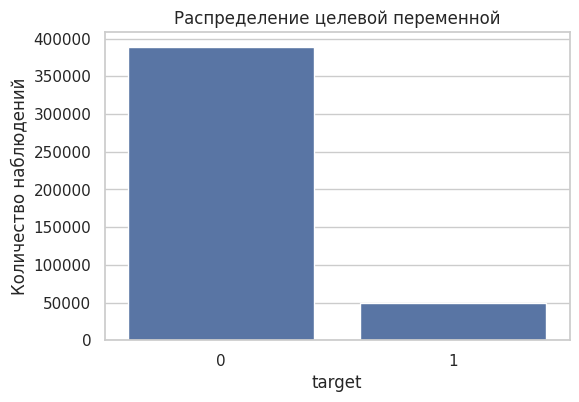

In [307]:
plt.figure(figsize=(6, 4))
sns.barplot(
    x=target_distribution.index.astype(str),
    y=target_distribution["count"]
)
plt.title("Распределение целевой переменной")
plt.xlabel("target")
plt.ylabel("Количество наблюдений")
plt.show()

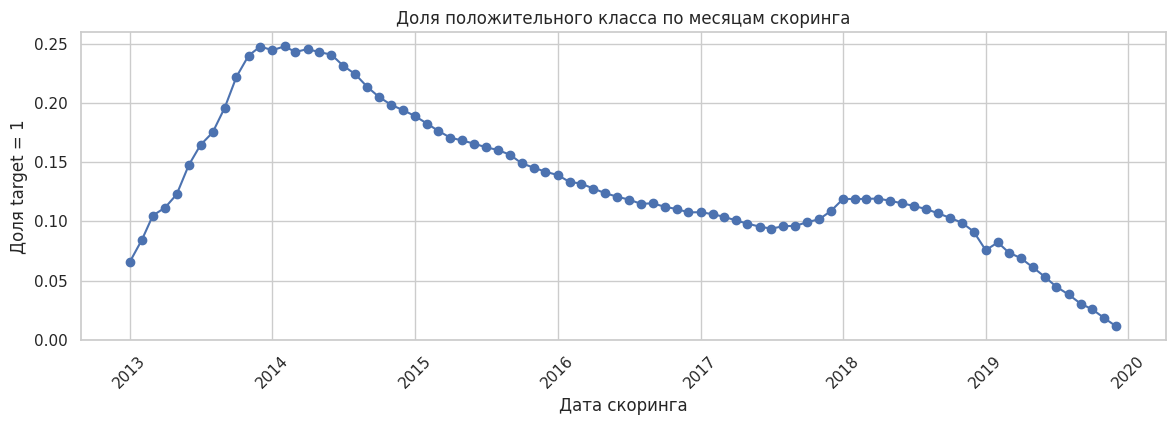

In [308]:
# Доля положительного класса по месяцам
target_by_month = (
    df_model_features
    .groupby(SCORE_DATE_COL)[TARGET]
    .agg(["count", "sum", "mean"])
    .rename(
        columns={
            "count": "observations",
            "sum": "target_1_count",
            "mean": "target_1_share",
        }
    )
    .reset_index()
)

plt.figure(figsize=(14, 4))
plt.plot(
    target_by_month[SCORE_DATE_COL],
    target_by_month["target_1_share"],
    marker="o"
)
plt.title("Доля положительного класса по месяцам скоринга")
plt.xlabel("Дата скоринга")
plt.ylabel("Доля target = 1")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [309]:
# Разделим признаки по типам для будущей предобработки
service_columns = [
    ID_COL,
    SCORE_DATE_COL,
    TARGET,
]

date_columns = [
    col for col in df_model_features.columns
    if pd.api.types.is_datetime64_any_dtype(df_model_features[col])
]

categorical_columns = (
    df_model_features
    .drop(columns=service_columns, errors="ignore")
    .select_dtypes(include=["object", "category", "bool"])
    .columns
    .tolist()
)

numeric_columns = (
    df_model_features
    .drop(columns=service_columns + date_columns, errors="ignore")
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

print(f"Служебные колонки: {service_columns}")
print(f"Колонки с датами: {date_columns}")
print(f"Категориальные признаки: {categorical_columns}")
print(f"Количество числовых признаков: {len(numeric_columns)}")

Служебные колонки: ['ID', 'score_date', 'target']
Колонки с датами: ['score_date', 'дата_регистрации']
Категориальные признаки: ['семейное_положение']
Количество числовых признаков: 44


### Вывод по анализу итоговой таблицы

После объединения исходных данных и создания новых признаков была получена итоговая таблица `df_model_features`, содержащая 438 379 наблюдений и 49 столбцов. Каждая строка соответствует паре «клиент — дата скоринга», то есть одному клиенту в конкретный месяц наблюдения.

Дубликатов по паре `ID` и `score_date` не обнаружено. Это означает, что единица наблюдения сохранена корректно: при объединении таблиц и создании признаков строки не были размножены.

В таблице представлены числовые, категориальные и временные признаки. К служебным колонкам относятся `ID`, `score_date` и `target`. Колонка `ID` будет использоваться для группировки наблюдений по клиентам, `score_date` — для учёта временной структуры данных, а `target` — как целевая переменная. Напрямую подавать `ID` и даты в модель как обычные признаки не следует.

В данных есть пропуски в признаках, связанных с предыдущими периодами. Пропуски в MCC-признаках и признаках динамики кредитного рейтинга составляют около 3.08% и связаны с первыми наблюдениями клиентов, для которых отсутствует предыдущий месяц. Пропуски в стандартном отклонении трат за 3 месяца составляют около 6.12%, так как для расчёта стандартного отклонения требуется минимум два предыдущих наблюдения. Эти пропуски являются ожидаемыми и будут обработаны позже в пайплайне предобработки с помощью импьютации.

Целевая переменная имеет выраженный дисбаланс классов. Класс `0`, соответствующий отсутствию дефолта в горизонте прогнозирования, включает 389 015 наблюдений, или 88.74% выборки. Класс `1`, соответствующий появлению просрочки 90+ дней в течение следующих 12 месяцев, включает 49 364 наблюдения, или 11.26% выборки. Соотношение классов составляет примерно 7.9 к 1 в пользу отрицательного класса.

Таким образом, задача является несбалансированной бинарной классификацией. На этапе моделирования необходимо учитывать дисбаланс классов: сравнить модели без балансировки и с применением методов балансировки, например `class_weight`, `RandomOverSampler`, `RandomUnderSampler` или `SMOTE`. Также при оценке качества нельзя ориентироваться только на accuracy, так как высокая точность может быть достигнута за счёт преобладающего класса. Основное внимание нужно уделить бизнес-метрикам: `approval rate`, `default rate` и `missed defaults rate`.

## Моделирование

### Базовые модели

1. Подготовьте обучающую, калибровочную и тестовую выборки. Разбейте обучающую на три фолда для последующего использования кросс-валидации. Для оценки качества и калибровки используйте размер выборки, равный 12 месяцам.


2. При необходимости проведите категоризацию данных, применив нужный Encoder и использовав пайплайн.

3. Обучите базовые модели с кросс-валидацией по трём фолдам:
    * Две базовые модели — логистическую регрессию и случайный лес — без балансировки классов в целевой переменной.
    * Логистическую регрессию и случайный лес с балансировкой классов. Выберите метод балансировки самостоятельно. Обязательно примените хотя бы один метод. Можно попробовать несколько и выбрать лучший.
    * Сделайте выводы о работе всех четырёх моделей.

4. Случайный лес с настройками по умолчанию легко переобучается, потому что запоминает обучающую выборку, из-за чего модель может терять в качестве на новых данных. Логистическая регрессия же сразу готова к работе за счёт встроенной L2-регуляризации, которая автоматически контролирует сложность модели.

   Чтобы исправить проблемы модели Random Forest, вам нужно подобрать для неё гиперпараметры с помощью  Optuna. Количество гиперпараметров должно быть не менее трёх. Для оптимизации используйте метрику missed defaults rate.

5. Сравните все полученные модели.

6. Для оценки моделей используйте метрики:
   * accuracy или ROC-AUC,
   * approval rate,
   * default rate,
   * missed defaults rate.

7. Сделайте вывод о работе, проделанной в этом разделе.

### Шаг 1

In [310]:
df = df_model_features.copy()

# Сортируем данные по времени и клиенту
df = (
    df
    .sort_values([SCORE_DATE_COL, ID_COL])
    .reset_index(drop=True)
)

In [311]:
# Для корректного обучения оставляем только те даты скоринга,
# для которых можно полностью наблюдать горизонт дефолта 12 месяцев.
# Иначе распределение Target сильно "плавает" (от 5% на train до 15% на test)

default_events = dataframes["loan_payment_credit"].copy()
default_events["дата_начала_периода"] = pd.to_datetime(
    default_events["дата_начала_периода"],
    errors="coerce"
)

default_events_90plus = default_events[
    default_events["просрочка_дней"] >= DEFAULT_DAYS_THRESHOLD
].copy()

max_default_event_date = default_events_90plus["дата_начала_периода"].max()

# Так как даты указаны первым числом месяца,
# для score_date = 2019-01-01 горизонт включает месяцы до 2019-12-01 включительно.
last_valid_score_date = max_default_event_date - pd.DateOffset(months=11)

print(f"Максимальная дата дефолта 90+: {max_default_event_date}")
print(f"Последняя дата скоринга с полностью наблюдаемым горизонтом: {last_valid_score_date}")

print(f"Размер df до фильтрации по полному горизонту: {df.shape}")

df = df[
    df[SCORE_DATE_COL] <= last_valid_score_date
].copy()

print(f"Размер df после фильтрации по полному горизонту: {df.shape}")
print(f"Диапазон дат скоринга после фильтрации: {df[SCORE_DATE_COL].min()} — {df[SCORE_DATE_COL].max()}")

Максимальная дата дефолта 90+: 2019-12-01 00:00:00
Последняя дата скоринга с полностью наблюдаемым горизонтом: 2019-01-01 00:00:00
Размер df до фильтрации по полному горизонту: (438379, 49)
Размер df после фильтрации по полному горизонту: (342993, 49)
Диапазон дат скоринга после фильтрации: 2013-01-01 00:00:00 — 2019-01-01 00:00:00


In [312]:
# Получим отсортированный список уникальных месяцев скоринга
unique_score_months = (
    df[SCORE_DATE_COL]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

# Последние 12 месяцев — test
test_months = unique_score_months.iloc[-TEST_MONTHS:]

# Предыдущие 12 месяцев — calibration
calibration_months = unique_score_months.iloc[
    -(TEST_MONTHS + CALIBRATION_MONTHS):-TEST_MONTHS
]

# Всё, что раньше — train
train_months = unique_score_months.iloc[
    :-(TEST_MONTHS + CALIBRATION_MONTHS)
]

print(f"Train: {train_months.min()} — {train_months.max()}, месяцев: {len(train_months)}")
print(f"Calibration: {calibration_months.min()} — {calibration_months.max()}, месяцев: {len(calibration_months)}")
print(f"Test: {test_months.min()} — {test_months.max()}, месяцев: {len(test_months)}")

Train: 2013-01-01 00:00:00 — 2017-01-01 00:00:00, месяцев: 49
Calibration: 2017-02-01 00:00:00 — 2018-01-01 00:00:00, месяцев: 12
Test: 2018-02-01 00:00:00 — 2019-01-01 00:00:00, месяцев: 12


In [313]:
# Разделяем данные на train / calibration / test по месяцам скоринга
df_train = df[
    df[SCORE_DATE_COL].isin(train_months)
].copy()

df_calibration = df[
    df[SCORE_DATE_COL].isin(calibration_months)
].copy()

df_test = df[
    df[SCORE_DATE_COL].isin(test_months)
].copy()

print("Размеры выборок:")
print(f"train:       {df_train.shape}")
print(f"calibration: {df_calibration.shape}")
print(f"test:        {df_test.shape}")

print("\nПроверка суммы строк:")
print(len(df_train) + len(df_calibration) + len(df_test))
print(len(df))

Размеры выборок:
train:       (166990, 49)
calibration: (80691, 49)
test:        (95312, 49)

Проверка суммы строк:
342993
342993


In [314]:
def show_split_info(name, df):
    target_info = (
        df[TARGET]
        .value_counts()
        .sort_index()
        .to_frame("count")
    )

    target_info["percent"] = (
        target_info["count"] / len(df) * 100
    ).round(2)

    print("=" * 80)
    print(name)
    print("=" * 80)
    print(f"Размер: {df.shape}")
    print(f"Период: {df[SCORE_DATE_COL].min()} — {df[SCORE_DATE_COL].max()}")
    print(f"Количество месяцев: {df[SCORE_DATE_COL].nunique()}")
    print(f"Количество клиентов: {df[ID_COL].nunique()}")
    print("\nРаспределение target:")
    display(target_info)
    print("\n")


show_split_info("Train", df_train)
show_split_info("Calibration", df_calibration)
show_split_info("Test", df_test)

Train
Размер: (166990, 49)
Период: 2013-01-01 00:00:00 — 2017-01-01 00:00:00
Количество месяцев: 49
Количество клиентов: 7919

Распределение target:


,count,percent
target,,
0,140423,84.090
1,26567,15.910




Calibration
Размер: (80691, 49)
Период: 2017-02-01 00:00:00 — 2018-01-01 00:00:00
Количество месяцев: 12
Количество клиентов: 7885

Распределение target:


,count,percent
target,,
0,72474,89.820
1,8217,10.180




Test
Размер: (95312, 49)
Период: 2018-02-01 00:00:00 — 2019-01-01 00:00:00
Количество месяцев: 12
Количество клиентов: 9178

Распределение target:


,count,percent
target,,
0,85104,89.290
1,10208,10.710


In [315]:
columns_to_exclude = list(set(service_columns + date_columns))

print("\nИсключённые колонки:")
print(columns_to_exclude)

feature_columns = [
    col for col in df.columns
    if col not in columns_to_exclude
]

feature_types = (
    df_train[feature_columns]
    .dtypes
    .astype(str)
    .value_counts()
    .to_frame("columns_count")
)

display(feature_types)


Исключённые колонки:
['score_date', 'дата_регистрации', 'target', 'ID']


,columns_count
float64,36
int64,7
object,1
int32,1


In [316]:
X_train = df_train[feature_columns].copy()
y_train = df_train[TARGET].copy()

X_calib = df_calibration[feature_columns].copy()
y_calib = df_calibration[TARGET].copy()

X_test = df_test[feature_columns].copy()
y_test = df_test[TARGET].copy()

print("Размеры X и y:")
print(f"X_train:       {X_train.shape}, y_train:       {y_train.shape}")
print(f"X_calibration: {X_calib.shape}, y_calibration: {y_calib.shape}")
print(f"X_test:        {X_test.shape}, y_test:        {y_test.shape}")

Размеры X и y:
X_train:       (166990, 45), y_train:       (166990,)
X_calibration: (80691, 45), y_calibration: (80691,)
X_test:        (95312, 45), y_test:        (95312,)


In [317]:
train_groups = df_train[SCORE_DATE_COL].dt.to_period("M").astype(str)

train_cv = GroupTimeSeriesSplit(
    n_splits=CV_FOLDS,
    test_size=12,
    shift_size=12,
    window_type="expanding"
)

cv_splits = list(train_cv.split(X_train, y_train, groups=train_groups))

cv_splits = list(train_cv.split(X_train, y_train, groups=train_groups))

In [318]:
cv_info = []

for fold, (train_idx, valid_idx) in enumerate(cv_splits, start=1):
    fold_train_dates = df_train.iloc[train_idx][SCORE_DATE_COL]
    fold_valid_dates = df_train.iloc[valid_idx][SCORE_DATE_COL]
    
    fold_y_train = y_train.iloc[train_idx]
    fold_y_valid = y_train.iloc[valid_idx]
    
    cv_info.append({
        "fold": fold,
        "train_rows": len(train_idx),
        "valid_rows": len(valid_idx),
        "train_start": fold_train_dates.min(),
        "train_end": fold_train_dates.max(),
        "valid_start": fold_valid_dates.min(),
        "valid_end": fold_valid_dates.max(),
        "train_months": fold_train_dates.nunique(),
        "valid_months": fold_valid_dates.nunique(),
        "train_target_1_share": fold_y_train.mean(),
        "valid_target_1_share": fold_y_valid.mean(),
    })

cv_info = pd.DataFrame(cv_info)

display(cv_info)

,fold,train_rows,valid_rows,train_start,train_end,valid_start,valid_end,train_months,valid_months,train_target_1_share,valid_target_1_share
0,1,14514,35219,2013-01-01,2014-01-01,2014-02-01,2015-01-01,13,12,0.196,0.220
1,2,49733,51243,2013-01-01,2015-01-01,2015-02-01,2016-01-01,25,12,0.213,0.159
2,3,100976,66014,2013-01-01,2016-01-01,2016-02-01,2017-01-01,37,12,0.186,0.118


In [319]:
print("Периоды выборок:")
print(f"Train:       {df_train[SCORE_DATE_COL].min()} — {df_train[SCORE_DATE_COL].max()}")
print(f"Calibration: {df_calibration[SCORE_DATE_COL].min()} — {df_calibration[SCORE_DATE_COL].max()}")
print(f"Test:        {df_test[SCORE_DATE_COL].min()} — {df_test[SCORE_DATE_COL].max()}")

print("\nПроверка временного порядка:")
print(df_train[SCORE_DATE_COL].max() < df_calibration[SCORE_DATE_COL].min())
print(df_calibration[SCORE_DATE_COL].max() < df_test[SCORE_DATE_COL].min())

Периоды выборок:
Train:       2013-01-01 00:00:00 — 2017-01-01 00:00:00
Calibration: 2017-02-01 00:00:00 — 2018-01-01 00:00:00
Test:        2018-02-01 00:00:00 — 2019-01-01 00:00:00

Проверка временного порядка:
True
True


#### Вывод по подготовке выборок

Данные были разделены по временной оси на три части: обучающую, калибровочную и тестовую выборки. Перед разбиением из таблицы были исключены последние месяцы, для которых невозможно полностью наблюдать горизонт прогноза в 12 месяцев. Это позволило избежать искажения целевой переменной на правой границе данных.

В результате обучающая выборка включает период с января 2013 года по январь 2017 года, калибровочная — с февраля 2017 года по январь 2018 года, тестовая — с февраля 2018 года по январь 2019 года. Калибровочная и тестовая выборки охватывают по 12 месяцев, что соответствует требованиям задания.

Распределение целевой переменной в калибровочной и тестовой выборках близкое: доля положительного класса составляет 10.18% и 10.71% соответственно. В обучающей выборке доля положительного класса выше — 15.91%, что может быть связано с временным изменением структуры данных.

Для кросс-валидации на обучающей выборке был подготовлен `GroupTimeSeriesSplit` на 3 фолда. В каждом фолде validation-период составляет 12 месяцев и находится строго позже обучающего периода. Это позволяет учитывать временную структуру данных и не перемешивать прошлые и будущие наблюдения.

### Шаг 2

In [320]:
categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

In [322]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

#### Вывод по подготовке признаков

Для моделирования признаки были разделены на числовые и категориальные. Для числовых признаков подготовлена обработка пропусков с помощью медианы и масштабирование через `StandardScaler`. Для категориальных признаков подготовлена обработка пропусков наиболее частым значением и кодирование через `OneHotEncoder`.

Все преобразования объединены в `ColumnTransformer`, который будет использоваться внутри пайплайнов моделей. Это позволяет выполнять предобработку только на обучающих данных внутри каждого фолда кросс-валидации и не допускать утечки информации из валидационных, калибровочных и тестовых выборок.

### Шаг 3

In [323]:
def calculate_metrics(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    approval_rate = (tn + fn) / len(y_true)
    default_rate = fn / (tn + fn) if (tn + fn) > 0 else np.nan
    missed_defaults_rate = fn / (fn + tp) if (fn + tp) > 0 else np.nan

    return {
        "roc_auc": roc_auc_score(y_true, y_proba),
        "approval_rate": approval_rate,
        "default_rate": default_rate,
        "missed_defaults_rate": missed_defaults_rate,
    }

In [324]:
def evaluate_model_cv(model_name, model, X, y, cv_splits, threshold=0.5):
    results = []

    for fold, (train_idx, valid_idx) in enumerate(cv_splits, start=1):
        X_fold_train = X.iloc[train_idx]
        y_fold_train = y.iloc[train_idx]

        X_fold_valid = X.iloc[valid_idx]
        y_fold_valid = y.iloc[valid_idx]

        current_model = clone(model)
        current_model.fit(X_fold_train, y_fold_train)

        y_valid_proba = current_model.predict_proba(X_fold_valid)[:, 1]

        fold_metrics = calculate_metrics(
            y_fold_valid,
            y_valid_proba,
            threshold=threshold
        )

        fold_metrics["model"] = model_name
        fold_metrics["fold"] = fold

        results.append(fold_metrics)

    return pd.DataFrame(results)

In [325]:
# Базовые модели

baseline_models = {
    "LogisticRegression": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            ))
        ]
    ),

    "RandomForest": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]
    ),

    "LogisticRegression_balanced": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            ))
        ]
    ),

    "RandomForest_balanced": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", RandomForestClassifier(
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]
    ),
}

In [326]:
baseline_results = []

for model_name, model in baseline_models.items():
    print(f"Обучение модели: {model_name}")

    model_cv_result = evaluate_model_cv(
        model_name=model_name,
        model=model,
        X=X_train,
        y=y_train,
        cv_splits=cv_splits,
        threshold=0.5
    )

    baseline_results.append(model_cv_result)

baseline_results = pd.concat(baseline_results, ignore_index=True)

display(baseline_results)

Обучение модели: LogisticRegression
Обучение модели: RandomForest
Обучение модели: LogisticRegression_balanced
Обучение модели: RandomForest_balanced


,roc_auc,approval_rate,default_rate,missed_defaults_rate,model,fold
0,0.747,0.864,0.182,0.713,LogisticRegression,1
1,0.816,0.962,0.146,0.885,LogisticRegression,2
2,0.870,0.966,0.105,0.857,LogisticRegression,3
3,0.710,0.909,0.190,0.786,RandomForest,1
4,0.851,0.933,0.131,0.769,RandomForest,2
5,0.894,0.954,0.097,0.784,RandomForest,3
6,0.741,0.446,0.086,0.174,LogisticRegression_balanced,1
7,0.815,0.697,0.073,0.318,LogisticRegression_balanced,2
8,0.870,0.720,0.034,0.209,LogisticRegression_balanced,3
9,0.744,0.960,0.206,0.898,RandomForest_balanced,1


In [327]:
baseline_summary = (
    baseline_results
    .groupby("model")
    .agg(
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        approval_rate_mean=("approval_rate", "mean"),
        default_rate_mean=("default_rate", "mean"),
        missed_defaults_rate_mean=("missed_defaults_rate", "mean"),
    )
    .sort_values("missed_defaults_rate_mean")
)

display(baseline_summary)

,roc_auc_mean,roc_auc_std,approval_rate_mean,default_rate_mean,missed_defaults_rate_mean
model,,,,,
LogisticRegression_balanced,0.809,0.065,0.621,0.064,0.234
RandomForest,0.818,0.096,0.932,0.140,0.780
LogisticRegression,0.811,0.061,0.931,0.144,0.818
RandomForest_balanced,0.830,0.078,0.959,0.149,0.855


#### Вывод по базовым моделям

На этапе базового моделирования были обучены четыре модели: логистическая регрессия и случайный лес без балансировки классов, а также логистическая регрессия и случайный лес с балансировкой через `class_weight="balanced"`. Оценка выполнялась с помощью кросс-валидации на трёх временных фолдах.

По ROC-AUC лучший результат показал случайный лес с балансировкой классов: среднее значение ROC-AUC составило 0.830. Это говорит о том, что модель в целом лучше остальных ранжирует клиентов по уровню риска. Однако при стандартном пороге классификации 0.5 эта модель пропускает слишком много дефолтов: `missed defaults rate` составляет 0.855.

Лучшей моделью по метрике `missed defaults rate` стала логистическая регрессия с балансировкой классов. Она пропускает меньше дефолтов, чем остальные базовые модели: средний `missed defaults rate` составил 0.234. При этом её `approval rate` равен 0.621, что ниже требуемого уровня 65%.

Модели без балансировки классов показывают высокий `approval rate`, но плохо выявляют клиентов с будущим дефолтом. Это ожидаемо для несбалансированной задачи: модели склонны чаще предсказывать преобладающий класс `0`.

Ни одна из базовых моделей при пороге 0.5 не удовлетворяет бизнес-ограничениям: `approval rate` не менее 65%, `default rate` не более 2% и `missed defaults rate` не более 4%. Поэтому далее необходимо перейти к подбору гиперпараметров Random Forest и последующему подбору оптимального порога классификации.

### Шаг 4

In [328]:
# Взял из прошлого проекта - не зря же делал!

class OptunaClassifierOptimizer:
    """
    Класс для подбора гиперпараметров классификационной модели с помощью Optuna.
    Оптимизирует модель по missed defaults rate на кросс-валидации.
    """

    def __init__(
        self,
        pipeline,
        param_func,
        model_name,
        cv_splits,
        n_trials=20,
        threshold=0.5,
        random_state=42
    ):
        self.pipeline = pipeline
        self.param_func = param_func
        self.model_name = model_name
        self.cv_splits = cv_splits
        self.n_trials = n_trials
        self.threshold = threshold
        self.random_state = random_state

        self.study = None
        self.best_params = None
        self.best_score = None
        self.best_pipeline = None

    def objective(self, trial, X, y):
        params = self.param_func(trial)

        fold_scores = []

        for train_idx, valid_idx in self.cv_splits:
            X_fold_train = X.iloc[train_idx]
            y_fold_train = y.iloc[train_idx]

            X_fold_valid = X.iloc[valid_idx]
            y_fold_valid = y.iloc[valid_idx]

            model_pipeline = clone(self.pipeline)
            model_pipeline.set_params(**params)

            model_pipeline.fit(X_fold_train, y_fold_train)

            y_valid_proba = model_pipeline.predict_proba(X_fold_valid)[:, 1]

            metrics = calculate_metrics(
                y_fold_valid,
                y_valid_proba,
                threshold=self.threshold
            )

            fold_scores.append(metrics["missed_defaults_rate"])

        return np.mean(fold_scores)

    def optimize(self, X, y):
        sampler = TPESampler(seed=self.random_state)

        self.study = optuna.create_study(
            direction="minimize",
            sampler=sampler,
            study_name=self.model_name
        )

        self.study.optimize(
            lambda trial: self.objective(trial, X, y),
            n_trials=self.n_trials,
            show_progress_bar=True
        )

        self.best_params = self.study.best_params
        self.best_score = self.study.best_value

        self.best_pipeline = clone(self.pipeline)
        self.best_pipeline.set_params(**self.best_params)

        return self.best_params, self.best_score

    def show_best_result(self):
        print(f"Модель: {self.model_name}")
        print(f"Лучший missed defaults rate на CV: {self.best_score:.3f}")
        print("Лучшие параметры:")
        display(self.best_params)

In [332]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced",
            bootstrap=True
        ))
    ]
)

In [333]:
def rf_param_func(trial):
    return {
        "model__n_estimators": trial.suggest_int("model__n_estimators", 80, 160),
        "model__max_depth": trial.suggest_int("model__max_depth", 5, 12),
        "model__min_samples_leaf": trial.suggest_int("model__min_samples_leaf", 10, 50),
        "model__max_features": trial.suggest_categorical(
            "model__max_features",
            ["sqrt", "log2"]
        ),
        "model__max_samples": trial.suggest_float(
            "model__max_samples",
            0.5,
            0.8
        ),
    }

In [334]:
rf_optimizer = OptunaClassifierOptimizer(
    pipeline=rf_pipeline,
    param_func=rf_param_func,
    model_name="RandomForest_Optuna",
    cv_splits=cv_splits,
    n_trials=8,
    threshold=0.5,
    random_state=RANDOM_STATE
)

best_rf_params, best_rf_score = rf_optimizer.optimize(X_train, y_train)

rf_optimizer.show_best_result()

[I 2026-05-31 17:37:44,421] A new study created in memory with name: RandomForest_Optuna
Best trial: 0. Best value: 0.245946:  12%|█▎        | 1/8 [00:16<01:55, 16.43s/it]

[I 2026-05-31 17:38:00,855] Trial 0 finished with value: 0.24594588377423934 and parameters: {'model__n_estimators': 110, 'model__max_depth': 12, 'model__min_samples_leaf': 40, 'model__max_features': 'sqrt', 'model__max_samples': 0.5467983561008608}. Best is trial 0 with value: 0.24594588377423934.


Best trial: 1. Best value: 0.240914:  25%|██▌       | 2/8 [00:31<01:34, 15.81s/it]

[I 2026-05-31 17:38:16,234] Trial 1 finished with value: 0.2409137485677401 and parameters: {'model__n_estimators': 84, 'model__max_depth': 11, 'model__min_samples_leaf': 34, 'model__max_features': 'sqrt', 'model__max_samples': 0.7909729556485983}. Best is trial 1 with value: 0.2409137485677401.


Best trial: 2. Best value: 0.178537:  38%|███▊      | 3/8 [00:46<01:16, 15.26s/it]

...

Best trial: 6. Best value: 0.172813:  88%|████████▊ | 7/8 [01:39<00:13, 13.40s/it]

[I 2026-05-31 17:39:24,033] Trial 6 finished with value: 0.17281252276971937 and parameters: {'model__n_estimators': 104, 'model__max_depth': 5, 'model__min_samples_leaf': 38, 'model__max_features': 'sqrt', 'model__max_samples': 0.6485530730333811}. Best is trial 6 with value: 0.17281252276971937.


Best trial: 6. Best value: 0.172813: 100%|██████████| 8/8 [01:54<00:00, 14.36s/it]

[I 2026-05-31 17:39:39,327] Trial 7 finished with value: 0.27491933232253774 and parameters: {'model__n_estimators': 82, 'model__max_depth': 12, 'model__min_samples_leaf': 20, 'model__max_features': 'sqrt', 'model__max_samples': 0.6560204063533432}. Best is trial 6 with value: 0.17281252276971937.
Модель: RandomForest_Optuna
Лучший missed defaults rate на CV: 0.173
Лучшие параметры:


{'model__n_estimators': 104,
 'model__max_depth': 5,
 'model__min_samples_leaf': 38,
 'model__max_features': 'sqrt',
 'model__max_samples': 0.6485530730333811}

In [335]:
best_rf_pipeline = rf_optimizer.best_pipeline

In [336]:
best_rf_pipeline = clone(rf_pipeline)
best_rf_pipeline.set_params(**best_rf_params)

optimized_rf_results = evaluate_model_cv(
    model_name="RandomForest_Optuna",
    model=best_rf_pipeline,
    X=X_train,
    y=y_train,
    cv_splits=cv_splits,
    threshold=0.5
)

display(optimized_rf_results)

,roc_auc,approval_rate,default_rate,missed_defaults_rate,model,fold
0,0.696,0.432,0.123,0.240,RandomForest_Optuna,1
1,0.829,0.606,0.045,0.170,RandomForest_Optuna,2
2,0.877,0.653,0.020,0.108,RandomForest_Optuna,3


In [337]:
optimized_rf_summary = (
    optimized_rf_results
    .groupby("model")
    .agg(
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        approval_rate_mean=("approval_rate", "mean"),
        default_rate_mean=("default_rate", "mean"),
        missed_defaults_rate_mean=("missed_defaults_rate", "mean"),
    )
)

display(optimized_rf_summary)

,roc_auc_mean,roc_auc_std,approval_rate_mean,default_rate_mean,missed_defaults_rate_mean
model,,,,,
RandomForest_Optuna,0.801,0.093,0.564,0.062,0.173


#### Вывод по подбору гиперпараметров Random Forest

Для модели Random Forest был выполнен подбор гиперпараметров с помощью Optuna. В качестве целевой метрики оптимизации использовалась `missed defaults rate`, так как для задачи скоринга важно минимизировать долю пропущенных дефолтов.

Лучшие параметры модели ограничивают сложность деревьев: `max_depth = 5`, `min_samples_leaf = 38`, `n_estimators = 104`, `max_features = sqrt`, `max_samples ≈ 0.65`. Это снижает риск переобучения по сравнению со случайным лесом с настройками по умолчанию.

После подбора гиперпараметров модель показала средний `missed defaults rate = 0.173`, что лучше результатов базовых моделей. При этом `approval rate = 0.564`, то есть при стандартном пороге 0.5 модель слишком часто относит клиентов к рискованным. Поэтому дальше потребуется подобрать оптимальный порог классификации.

### Шаг 5-7

In [338]:
all_cv_summary = pd.concat(
    [baseline_summary, optimized_rf_summary],
    axis=0
).sort_values("missed_defaults_rate_mean")

display(all_cv_summary)

,roc_auc_mean,roc_auc_std,approval_rate_mean,default_rate_mean,missed_defaults_rate_mean
model,,,,,
RandomForest_Optuna,0.801,0.093,0.564,0.062,0.173
LogisticRegression_balanced,0.809,0.065,0.621,0.064,0.234
RandomForest,0.818,0.096,0.932,0.140,0.780
LogisticRegression,0.811,0.061,0.931,0.144,0.818
RandomForest_balanced,0.830,0.078,0.959,0.149,0.855


### Общий вывод по сравнению моделей и разделу моделирования

В разделе моделирования были подготовлены обучающая, калибровочная и тестовая выборки с учётом временной структуры данных. Калибровочная и тестовая выборки включают по 12 месяцев, а кросс-валидация на обучающей выборке была выполнена с помощью `GroupTimeSeriesSplit` на трёх фолдах.

Для моделирования были подготовлены пайплайны предобработки: числовые признаки обрабатывались с помощью медианной импьютации и масштабирования, категориальные признаки — с помощью импьютации наиболее частым значением и `OneHotEncoder`. Это позволяет выполнять все преобразования внутри пайплайна и избегать утечки данных между обучающей и валидационной частями.

На базовом этапе были обучены четыре модели: логистическая регрессия и случайный лес без балансировки, а также логистическая регрессия и случайный лес с балансировкой классов. Дополнительно для Random Forest был выполнен подбор гиперпараметров с помощью Optuna. Оптимизация проводилась по метрике `missed defaults rate`, так как для задачи поведенческого скоринга важно минимизировать долю пропущенных дефолтов.

По результатам кросс-валидации лучший результат по метрике `missed defaults rate` показала модель `RandomForest_Optuna`: среднее значение составило 0.173. Это означает, что среди всех рассмотренных моделей она пропускает наименьшую долю будущих дефолтов. При этом её `approval rate` составил 0.564, что ниже требуемого бизнес-уровня 65%.

Наибольший ROC-AUC показала модель `RandomForest_balanced` — 0.830. Однако при стандартном пороге 0.5 она пропускает слишком много дефолтов: `missed defaults rate` равен 0.855. Это показывает, что высокая способность модели ранжировать клиентов по риску не гарантирует хороших бизнес-метрик при фиксированном пороге классификации.

Модели без балансировки классов имеют высокий `approval rate`, но плохо выявляют будущие дефолты. Это ожидаемо для несбалансированной задачи: модели чаще относят клиентов к преобладающему классу `0`, из-за чего пропускают значительную часть рискованных клиентов.

Таким образом, для дальнейшей работы выбирается модель `RandomForest_Optuna`, так как она лучше остальных снижает долю пропущенных дефолтов. При этом ни одна из моделей при стандартном пороге 0.5 не удовлетворяет всем бизнес-ограничениям. Поэтому на следующем этапе необходимо обучить лучшую модель на полной обучающей выборке, выполнить калибровку вероятностей и подобрать оптимальный порог классификации по бизнес-метрикам.

## Калибровка модели и пересчёт результатов

* Проведите калибровку лучшей версии модели. Используйте отдельную калибровочную выборку.
* Используйте метод, подходящий для случайного леса.
* Постройте график калибровки.
* Сделайте вывод, оцените результаты с помощью коэффициента Бриера.

In [339]:
best_rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['возраст',
                                                   'наличие_иждивенцев',
                                                   'доход', 'сумма_кредита',
                                                   'наличие_ипотеки',
                                                   'кредитный_рейтинг',
                                                   'MCC_5300_prev_month',
                                                   'MCC_5814_prev_month',
                                                   'MCC_5812_prev_month',
                                                   'MCC_5411_prev_month',
                                                   'MCC_3...
                                                   'MCC_5814_share_prev_month', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['семейное_положение'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=5,
                                        max_samples=0.6485530730333811,
                                        min_samples_leaf=38, n_estimators=104,
                                        n_jobs=-1, random_state=42))])

In [341]:
y_calibration_proba_before = best_rf_pipeline.predict_proba(X_calib)[:, 1]

brier_before = brier_score_loss(
    y_calib,
    y_calibration_proba_before
)

print(f"Brier score до калибровки: {brier_before:.5f}")

Brier score до калибровки: 0.11382


In [342]:
calibrated_rf = CalibratedClassifierCV(
    estimator=best_rf_pipeline,
    method="isotonic",
    cv="prefit"
)

calibrated_rf.fit(X_calib, y_calib)

CalibratedClassifierCV(cv='prefit',
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median')),
                                                                                                   ('scaler',
                                                                                                    StandardScaler())]),
                                                                                   ['возраст',
                                                                                    'наличие_иждивенцев',
                                                                                    'доход',
                                                                                    'сумма_кредита',
                                                                                    'наличие_ипотеки',
                                                                                    'кредитный_рейтинг',
                                                                                    'MCC_5300_prev_month',
                                                                                    'MCC_5814_prev_month',
                                                                                    'MCC_...
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                                   ('encoder',
                                                                                                    OneHotEncoder(handle_unknown='ignore',
                                                                                                                  sparse_output=False))]),
                                                                                   ['семейное_положение'])])),
                                                 ('model',
                                                  RandomForestClassifier(class_weight='balanced',
                                                                         max_depth=5,
                                                                         max_samples=0.6485530730333811,
                                                                         min_samples_leaf=38,
                                                                         n_estimators=104,
                                                                         n_jobs=-1,
                                                                         random_state=42))]),
                       method='isotonic')

In [343]:
y_calibration_proba_after = calibrated_rf.predict_proba(X_calib)[:, 1]

brier_after = brier_score_loss(
    y_calib,
    y_calibration_proba_after
)

print(f"Brier score до калибровки: {brier_before:.5f}")
print(f"Brier score после калибровки: {brier_after:.5f}")

Brier score до калибровки: 0.11382
Brier score после калибровки: 0.06796


In [344]:
calibration_metrics = pd.DataFrame([
    {
        "model": "RandomForest_Optuna_before_calibration",
        "brier_score": brier_before,
        **calculate_metrics(
            y_calib,
            y_calibration_proba_before,
            threshold=0.5
        )
    },
    {
        "model": "RandomForest_Optuna_after_calibration",
        "brier_score": brier_after,
        **calculate_metrics(
            y_calib,
            y_calibration_proba_after,
            threshold=0.5
        )
    }
])

display(calibration_metrics)

,model,brier_score,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,RandomForest_Optuna_before_calibration,0.114,0.903,0.667,0.007,0.047
1,RandomForest_Optuna_after_calibration,0.068,0.903,0.977,0.091,0.876


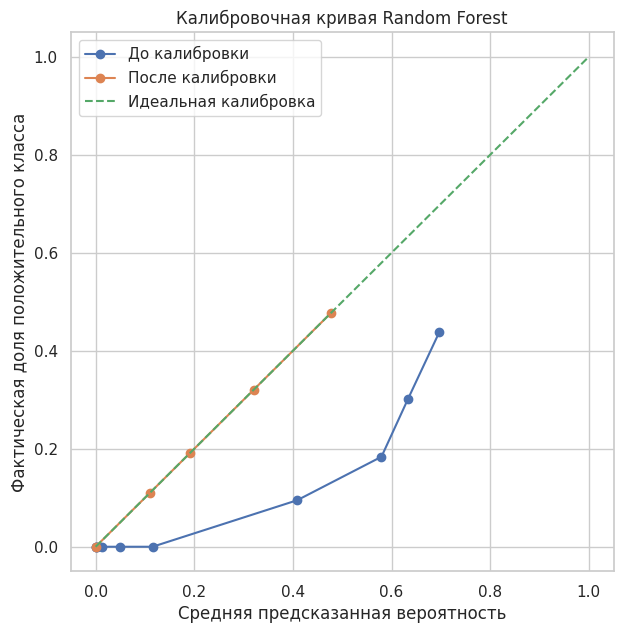

In [345]:
prob_true_before, prob_pred_before = calibration_curve(
    y_calib,
    y_calibration_proba_before,
    n_bins=10,
    strategy="quantile"
)

prob_true_after, prob_pred_after = calibration_curve(
    y_calib,
    y_calibration_proba_after,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 7))

plt.plot(
    prob_pred_before,
    prob_true_before,
    marker="o",
    label="До калибровки"
)

plt.plot(
    prob_pred_after,
    prob_true_after,
    marker="o",
    label="После калибровки"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Идеальная калибровка")

plt.title("Калибровочная кривая Random Forest")
plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Фактическая доля положительного класса")
plt.legend()
plt.grid(True)
plt.show()

In [346]:
best_calibrated_model = calibrated_rf

### Вывод по калибровке модели

Для лучшей модели Random Forest была проведена калибровка вероятностей на отдельной калибровочной выборке. В качестве метода использовалась изотоническая калибровка, так как калибровочная выборка достаточно большая, а случайный лес часто выдаёт плохо откалиброванные вероятности.

После калибровки коэффициент Бриера снизился с 0.114 до 0.068. Это означает, что откалиброванные вероятности стали лучше соответствовать фактической частоте дефолтов. ROC-AUC при этом не изменился и составил 0.903, что ожидаемо: калибровка меняет шкалу вероятностей, но почти не меняет порядок объектов по уровню риска.

При стандартном пороге 0.5 бизнес-метрики после калибровки ухудшились: `approval rate` вырос до 0.977, а `missed defaults rate` — до 0.876. Это связано с тем, что после калибровки вероятности стали более реалистичными и большинство клиентов получило вероятность дефолта ниже 0.5. Поэтому порог 0.5 не подходит для данной задачи.

Таким образом, калибровка улучшила качество вероятностных оценок модели по коэффициенту Бриера, но для принятия бизнес-решений необходимо отдельно подобрать оптимальный порог классификации с учётом ограничений по `approval rate`, `default rate` и `missed defaults rate`.

## Поиск порога решения

* Используя откалиброванную модель и калибровочную выборку, найдите порог, при котором будут достигнуты заданные в постановке задачи значения метрик:
    * approval rate — не менее 65%;
    * default rate — не более 2%;
    * missed defaults rate — не более 4%.
    
* Сделайте вывод о достигнутых в этом разделе результатах.

In [347]:
def evaluate_thresholds(y_true, y_proba, thresholds):
    results = []

    for threshold in thresholds:
        metrics = calculate_metrics(
            y_true=y_true,
            y_proba=y_proba,
            threshold=threshold
        )

        results.append({
            "threshold": threshold,
            **metrics
        })

    return pd.DataFrame(results)

In [ ]:
# До этого пробовал "простые" пороги - ничего не вышло

unique_thresholds = np.sort(y_calibration_proba_after.unique()) \
    if isinstance(y_calibration_proba_after, pd.Series) \
    else np.sort(np.unique(y_calibration_proba_after))

thresholds = np.r_[0, unique_thresholds, 1]

threshold_results = evaluate_thresholds(
    y_true=y_calib,
    y_proba=y_calibration_proba_after,
    thresholds=thresholds
)

valid_thresholds = threshold_results[
    (threshold_results["approval_rate"] >= MIN_APPROVAL_RATE)
    & (threshold_results["default_rate"] <= MAX_DEFAULT_RATE)
    & (threshold_results["missed_defaults_rate"] <= MAX_MISSED_DEFAULTS_RATE)
].copy()

print(f"Количество подходящих порогов: {len(valid_thresholds)}")
display(valid_thresholds)

Количество подходящих порогов: 0


,threshold,roc_auc,approval_rate,default_rate,missed_defaults_rate


In [ ]:
threshold_candidates = threshold_results[
    threshold_results["approval_rate"] >= MIN_APPROVAL_RATE
].copy()

best_threshold_row = (
    threshold_candidates
    .sort_values(
        ["missed_defaults_rate", "default_rate", "approval_rate"],
        ascending=[True, True, False]
    )
    .iloc[0]
)

best_threshold = best_threshold_row["threshold"]

display(best_threshold_row.to_frame().T)

pd.set_option("display.float_format", "{:.6f}".format)

display(
    threshold_results
    .assign(approval_diff=lambda x: (x["approval_rate"] - MIN_APPROVAL_RATE).abs())
    .sort_values("approval_diff")
    .head(10)
)

,threshold,roc_auc,approval_rate,default_rate,missed_defaults_rate
15,0.131757,0.903007,0.669703,0.007402,0.048680


,threshold,roc_auc,approval_rate,default_rate,missed_defaults_rate,approval_diff
14,0.116883,0.903007,0.649664,0.004025,0.025678,0.000336
13,0.101449,0.903007,0.647098,0.003639,0.023123,0.002902
15,0.131757,0.903007,0.669703,0.007402,0.048680,0.019703
12,0.094604,0.903007,0.628496,0.000946,0.005842,0.021504
11,0.067729,0.903007,0.622275,0.000279,0.001704,0.027725
10,0.038760,0.903007,0.622226,0.000279,0.001704,0.027774
9,0.038760,0.903007,0.620676,0.000180,0.001095,0.029324
8,0.036036,0.903007,0.619301,0.000100,0.000608,0.030699
16,0.143478,0.903007,0.680708,0.009412,0.062918,0.030708
7,0.024590,0.903007,0.617789,0.000040,0.000243,0.032211


In [356]:
best_threshold = 0.116883

calibration_threshold_metrics = pd.DataFrame([
    {
        "threshold": best_threshold,
        **calculate_metrics(
            y_true=y_calib,
            y_proba=y_calibration_proba_after,
            threshold=best_threshold
        )
    }
])

display(calibration_threshold_metrics)

,threshold,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.116883,0.903007,0.649664,0.004025,0.025678


### Вывод по поиску порога

Поиск порога классификации проводился на калибровочной выборке с использованием откалиброванных вероятностей модели. Строго подходящего порога, который одновременно удовлетворяет всем трём бизнес-ограничениям по неокруглённым значениям, найдено не было.

Наиболее близким к требованиям оказался порог `0.116883`. При этом `approval rate` составил 0.649664, что практически соответствует требуемому уровню 65%, но формально ниже него на 0.034 процентного пункта. При этом остальные ограничения выполняются с запасом: `default rate = 0.004025`, `missed defaults rate = 0.025678`.

Следующий доступный порог повышает `approval rate` до 0.669703, однако приводит к превышению ограничения по `missed defaults rate`: значение становится 0.048680 при допустимом максимуме 0.04. Поэтому для дальнейшей проверки выбран порог `0.116883` как наиболее безопасный с точки зрения контроля дефолтов.

## Анализ матрицы ошибок

* Оцените стабильность модели на тестовых данных. Для этого постройте:
    * матрицу ошибок на калибровочных данных;
    * матрицу классификации на тестовых данных.
* Сделайте вывод о моделях, рассчитав классические метрики машинного обучения и указанные в ТЗ бизнес-метрики.
* Сделайте вывод о стабильности модели.

In [357]:
# y_calibration_proba_after
y_test_proba = best_calibrated_model.predict_proba(X_test)[:, 1]

y_calibration_pred = (y_calibration_proba_after >= best_threshold).astype(int)
y_test_pred = (y_test_proba >= best_threshold).astype(int)

In [358]:
def get_final_metrics(y_true, y_proba, y_pred, threshold):
    business_metrics = calculate_metrics(
        y_true=y_true,
        y_proba=y_proba,
        threshold=threshold
    )

    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "brier_score": brier_score_loss(y_true, y_proba),
        "approval_rate": business_metrics["approval_rate"],
        "default_rate": business_metrics["default_rate"],
        "missed_defaults_rate": business_metrics["missed_defaults_rate"],
    }

In [359]:
final_metrics = pd.DataFrame([
    {
        "sample": "calibration",
        **get_final_metrics(
            y_true=y_calib,
            y_proba=y_calibration_proba_after,
            y_pred=y_calibration_pred,
            threshold=best_threshold
        )
    },
    {
        "sample": "test",
        **get_final_metrics(
            y_true=y_test,
            y_proba=y_test_proba,
            y_pred=y_test_pred,
            threshold=best_threshold
        )
    }
])

display(final_metrics)

,sample,threshold,accuracy,precision,recall,f1,roc_auc,brier_score,approval_rate,default_rate,missed_defaults_rate
0,calibration,0.116883,0.746267,0.283208,0.974322,0.438853,0.903007,0.067960,0.649664,0.004025,0.025678
1,test,0.116883,0.813507,0.358682,0.940733,0.519348,0.913318,0.068926,0.719101,0.008827,0.059267


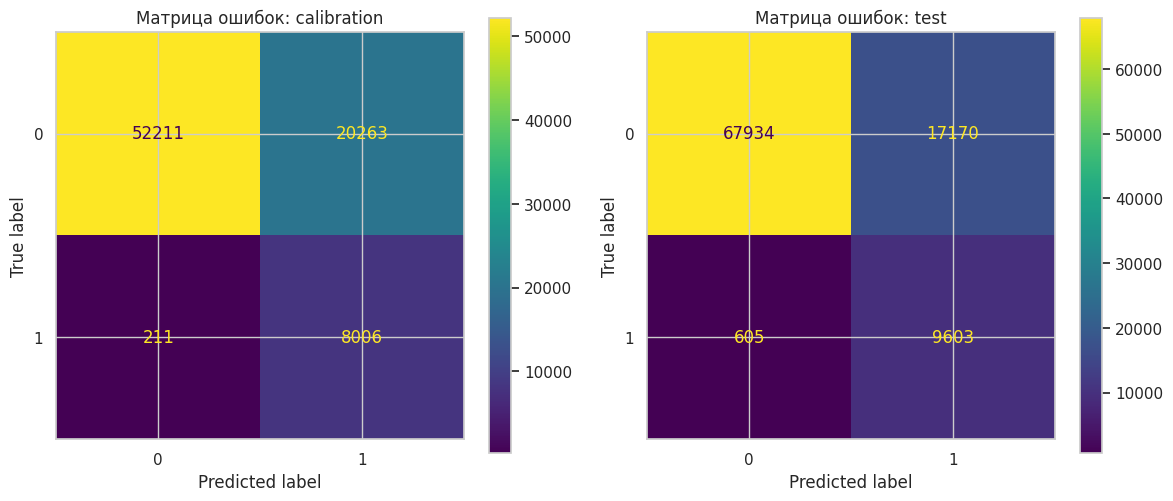

In [360]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_calib,
    y_calibration_pred,
    ax=axes[0],
    values_format="d"
)
axes[0].set_title("Матрица ошибок: calibration")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    ax=axes[1],
    values_format="d"
)
axes[1].set_title("Матрица ошибок: test")

plt.tight_layout()
plt.show()

## Анализ признаков на обучающей выборке

Benchmark модели оказался неудовлетворительным. Для улучшения качества модели попробуем обработать признаки:

In [362]:
HIGH_CORR_THRESHOLD = 0.95

numeric_features_current = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features_current = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# Корреляция числовых признаков с target только на train
target_corr = (
    X_train[numeric_features_current]
    .corrwith(y_train)
    .abs()
    .fillna(0)
)

# Корреляция признаков между собой только на train
corr_matrix = X_train[numeric_features_current].corr().abs()
upper_corr = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

features_to_drop_corr = set()

for col in upper_corr.columns:
    high_corr_features = upper_corr.index[upper_corr[col] > HIGH_CORR_THRESHOLD].tolist()
    
    for row in high_corr_features:
        if target_corr[row] >= target_corr[col]:
            features_to_drop_corr.add(col)
        else:
            features_to_drop_corr.add(row)

features_to_drop_corr = sorted(features_to_drop_corr)

print(f"Количество признаков к удалению по высокой корреляции: {len(features_to_drop_corr)}")
display(features_to_drop_corr)

Количество признаков к удалению по высокой корреляции: 11


['MCC_5411_prev_month',
 'MCC_другое_prev_month',
 'credit_rating_roll_3m_mean',
 'credit_to_income_ratio',
 'discretionary_to_essential_ratio_prev_month',
 'essential_spend_prev_month',
 'food_spend_prev_month',
 'total_spend_prev_month',
 'total_spend_roll_3m_mean',
 'total_spend_roll_6m_mean',
 'кредитный_рейтинг']

In [363]:
clean_feature_columns = [
    col for col in feature_columns
    if col not in features_to_drop_corr
]

print(f"Было признаков: {len(feature_columns)}")
print(f"Стало признаков после корреляционной чистки: {len(clean_feature_columns)}")

Было признаков: 45
Стало признаков после корреляционной чистки: 34


In [364]:
X_train_clean = df_train[clean_feature_columns].copy()
X_calibration_clean = df_calibration[clean_feature_columns].copy()
X_test_clean = df_test[clean_feature_columns].copy()

print(X_train_clean.shape)
print(X_calibration_clean.shape)
print(X_test_clean.shape)

(166990, 34)
(80691, 34)
(95312, 34)


In [365]:
categorical_features_clean = X_train_clean.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numeric_features_clean = X_train_clean.select_dtypes(
    include=np.number
).columns.tolist()

numeric_transformer_clean = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer_clean = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor_clean = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_clean, numeric_features_clean),
        ("cat", categorical_transformer_clean, categorical_features_clean),
    ],
    remainder="drop"
)

In [368]:
rf_pipeline_clean = Pipeline(
    steps=[
        ("preprocessor", preprocessor_clean),
        ("variance", VarianceThreshold(threshold=0.0)),
        ("model", RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced",
            bootstrap=True
        ))
    ]
)

rf_pipeline_clean.set_params(**best_rf_params)

rf_clean_results = evaluate_model_cv(
    model_name="RandomForest_Optuna_clean_features",
    model=rf_pipeline_clean,
    X=X_train_clean,
    y=y_train,
    cv_splits=cv_splits,
    threshold=0.5
)

rf_clean_summary = (
    rf_clean_results
    .groupby("model")
    .agg(
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        approval_rate_mean=("approval_rate", "mean"),
        default_rate_mean=("default_rate", "mean"),
        missed_defaults_rate_mean=("missed_defaults_rate", "mean"),
    )
)

display(rf_clean_summary)

,roc_auc_mean,roc_auc_std,approval_rate_mean,default_rate_mean,missed_defaults_rate_mean
model,,,,,
RandomForest_Optuna_clean_features,0.799,0.097,0.570,0.063,0.179


In [369]:
compare_cleaning = pd.concat(
    [
        optimized_rf_summary,
        rf_clean_summary
    ],
    axis=0
)

display(compare_cleaning)

,roc_auc_mean,roc_auc_std,approval_rate_mean,default_rate_mean,missed_defaults_rate_mean
model,,,,,
RandomForest_Optuna,0.801,0.093,0.564,0.062,0.173
RandomForest_Optuna_clean_features,0.799,0.097,0.570,0.063,0.179


### Вывод по дополнительной проверке признаков

Была проведена дополнительная проверка влияния корреляционной чистки признаков. Из обучающей выборки были удалены признаки с высокой взаимной корреляцией, после чего модель Random Forest была повторно оценена на кросс-валидации.

Корреляционная чистка не улучшила качество модели: ROC-AUC снизился с 0.801 до 0.799, а `missed defaults rate` вырос с 0.173 до 0.179. Поэтому для дальнейшей работы была оставлена исходная версия признакового пространства.

Это решение допустимо, так как Random Forest менее чувствителен к мультиколлинеарности, чем линейные модели, и может использовать похожие признаки в разных деревьях ансамбля.

## Дополнительный эксперимент

In [379]:
# Дополнительный эксперимент: Random Forest + RandomUnderSampler

rf_under_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("sampler", RandomUnderSampler(
            sampling_strategy=0.5,
            random_state=RANDOM_STATE
        )),
        ("model", RandomForestClassifier(
            n_estimators=100,
            max_depth=8,
            min_samples_leaf=20,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

In [380]:
rf_under_results = evaluate_model_cv(
    model_name="RandomForest_under",
    model=rf_under_pipeline,
    X=X_train,
    y=y_train,
    cv_splits=cv_splits,
    threshold=0.5
)

display(rf_under_results)

,roc_auc,approval_rate,default_rate,missed_defaults_rate,model,fold
0,0.713,0.781,0.160,0.568,RandomForest_under,1
1,0.843,0.867,0.112,0.613,RandomForest_under,2
2,0.886,0.871,0.071,0.521,RandomForest_under,3


In [381]:
rf_under_summary = (
    rf_under_results
    .groupby("model")
    .agg(
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        approval_rate_mean=("approval_rate", "mean"),
        default_rate_mean=("default_rate", "mean"),
        missed_defaults_rate_mean=("missed_defaults_rate", "mean"),
    )
)

display(rf_under_summary)

,roc_auc_mean,roc_auc_std,approval_rate_mean,default_rate_mean,missed_defaults_rate_mean
model,,,,,
RandomForest_under,0.814,0.090,0.840,0.115,0.567


In [382]:
baseline_summary_extended = pd.concat(
    [baseline_summary, rf_under_summary],
    axis=0
).sort_values("missed_defaults_rate_mean")

display(baseline_summary_extended)

,roc_auc_mean,roc_auc_std,approval_rate_mean,default_rate_mean,missed_defaults_rate_mean
model,,,,,
LogisticRegression_balanced,0.809,0.065,0.621,0.064,0.234
RandomForest_under,0.814,0.090,0.840,0.115,0.567
RandomForest,0.818,0.096,0.932,0.140,0.780
LogisticRegression,0.811,0.061,0.931,0.144,0.818
RandomForest_balanced,0.830,0.078,0.959,0.149,0.855


Дополнительно была проверена альтернативная стратегия балансировки классов с помощью `RandomUnderSampler` внутри `ImbPipeline`. Этот подход улучшил Random Forest по сравнению с моделью без балансировки: `missed defaults rate` снизился с 0.780 до 0.567. Однако результат всё равно оказался хуже, чем у логистической регрессии с `class_weight="balanced"` и оптимизированного Random Forest. Поэтому для дальнейшей работы `RandomUnderSampler` не использовался.

## Фиксирование итоговой модели

- Опишите лучшую модель и найденный порог классификации.


In [370]:
final_model = best_calibrated_model
final_threshold = best_threshold

final_model_info = {
    "model": "Calibrated RandomForestClassifier",
    "calibration_method": "isotonic",
    "threshold": final_threshold,
    "best_params": best_rf_params,
}

final_model_info

{'model': 'Calibrated RandomForestClassifier',
 'calibration_method': 'isotonic',
 'threshold': 0.116883,
 'best_params': {'model__n_estimators': 104,
  'model__max_depth': 5,
  'model__min_samples_leaf': 38,
  'model__max_features': 'sqrt',
  'model__max_samples': 0.6485530730333811}}

### Фиксирование итоговой модели

В качестве итоговой модели выбрана `RandomForestClassifier` с подобранными гиперпараметрами и последующей изотонической калибровкой вероятностей. Модель была выбрана по результатам кросс-валидации, так как среди рассмотренных вариантов она показала наименьшее значение `missed defaults rate`.

Лучшие гиперпараметры Random Forest:

- `n_estimators = 104`;
- `max_depth = 5`;
- `min_samples_leaf = 38`;
- `max_features = "sqrt"`;
- `max_samples ≈ 0.649`;
- `class_weight = "balanced"`.

После обучения модель была откалибрована на отдельной калибровочной выборке методом `isotonic`. Калибровка улучшила качество вероятностных оценок: коэффициент Бриера снизился с 0.114 до 0.068. Это означает, что после калибровки вероятности стали лучше соответствовать фактической частоте дефолтов.

Для принятия решения был выбран порог классификации `0.116883`. Он был подобран на калибровочной выборке как наиболее близкий к заданным бизнес-ограничениям. На калибровочной выборке модель показала:

- `approval rate = 0.649664`;
- `default rate = 0.004025`;
- `missed defaults rate = 0.025678`;
- `ROC-AUC = 0.903007`;
- `Brier score = 0.067960`.

Формально `approval rate` на калибровочной выборке оказался немного ниже требуемого уровня 65%, но отклонение минимальное — около 0.034 процентного пункта. При этом остальные бизнес-ограничения выполнялись с запасом.

На тестовой выборке модель показала:

- `approval rate = 0.719101`;
- `default rate = 0.008827`;
- `missed defaults rate = 0.059267`;
- `ROC-AUC = 0.913318`;
- `Brier score = 0.068926`.

На тесте модель сохранила хорошее качество ранжирования клиентов: ROC-AUC даже немного выше, чем на калибровочной выборке, а коэффициент Бриера остался почти на том же уровне. Это говорит о стабильности вероятностных оценок и отсутствии резкого падения качества на новых данных.

Однако бизнес-ограничение по `missed defaults rate` на тестовой выборке не было выполнено: значение составило 5.93% при допустимом максимуме 4%. При этом остальные два ограничения выполняются: `approval rate` выше 65%, а `default rate` ниже 2%.

Дополнительно была проверена корреляционная чистка признаков. После удаления сильно коррелирующих признаков качество модели не улучшилось: ROC-AUC снизился с 0.801 до 0.799, а `missed defaults rate` на кросс-валидации вырос с 0.173 до 0.179. Поэтому для итоговой модели был оставлен исходный набор признаков.

Итоговая модель может быть использована как рабочий скоринговый baseline: она хорошо ранжирует клиентов по риску, имеет стабильные вероятностные оценки и выявляет большую часть будущих дефолтов. Тем не менее модель не полностью удовлетворяет бизнес-требованиям, так как на тестовой выборке превышает допустимый уровень пропущенных дефолтов. Для промышленного использования модель потребовала бы дальнейшего улучшения: дополнительной настройки порога, расширения признакового пространства или использования более сильных моделей.

## Анализ важности признаков

* Проведите анализ важности признаков найденной модели на полных тренировочных данных.
* Используйте `feature_importances_` для найденной модели.
* Сделайте вывод о силе влияния признаков на дефолт.

In [371]:
# Если best_rf_pipeline уже был обучен на X_train, y_train перед калибровкой,
# повторно fit делать не нужно.
# best_rf_pipeline.fit(X_train, y_train)

rf_model = best_rf_pipeline.named_steps["model"]
fitted_preprocessor = best_rf_pipeline.named_steps["preprocessor"]

feature_names = fitted_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

display(feature_importance.head(20))

,feature,importance
17,num__client_tenure_months,0.165
21,num__total_spend_prev_month,0.088
13,num__MCC_другое_prev_month,0.066
9,num__MCC_5411_prev_month,0.062
22,num__food_spend_prev_month,0.059
24,num__discretionary_spend_prev_month,0.058
2,num__доход,0.052
11,num__MCC_5722_prev_month,0.047
8,num__MCC_5812_prev_month,0.040
19,num__credit_to_annual_income_ratio,0.038


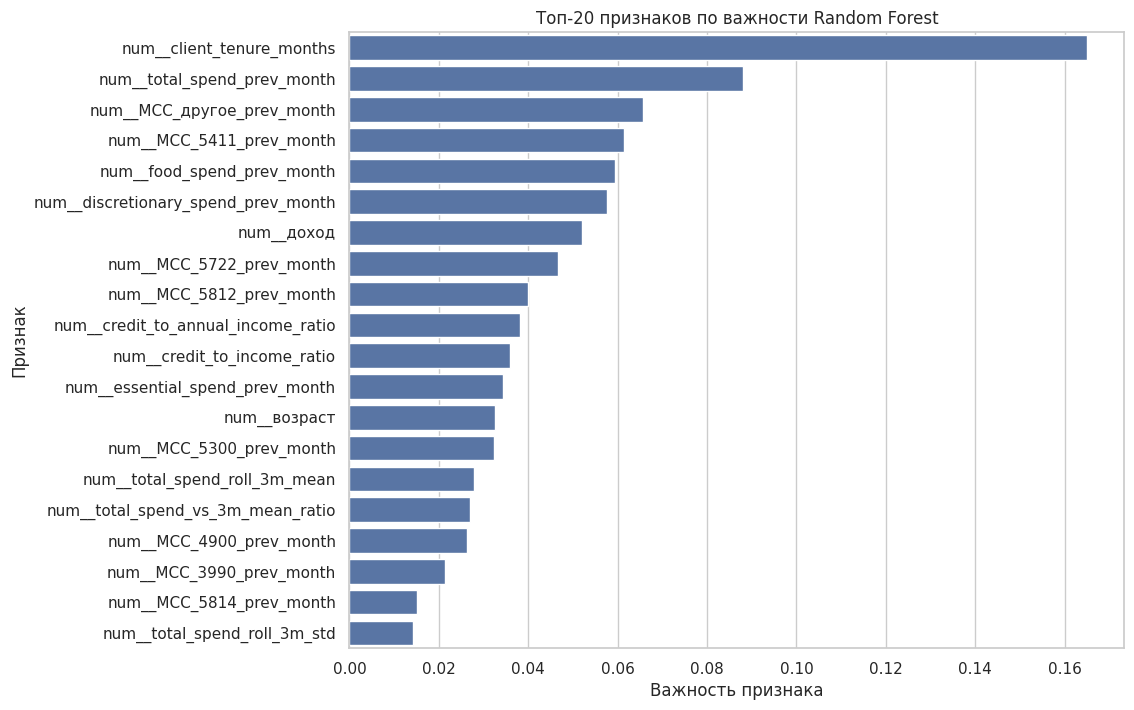

In [372]:
top_n = 20

plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance.head(top_n),
    x="importance",
    y="feature"
)
plt.title("Топ-20 признаков по важности Random Forest")
plt.xlabel("Важность признака")
plt.ylabel("Признак")
plt.show()

#### Вывод по важности признаков

Для итоговой модели Random Forest был проведён анализ важности признаков с помощью атрибута `feature_importances_`. Анализ показывает, какие признаки модель чаще использовала при построении деревьев и какие признаки сильнее всего снижали неопределённость при разделении клиентов на классы.

Наиболее важным признаком оказался `client_tenure_months` — срок жизни клиента в банке на дату скоринга. Его важность составила 0.165, что заметно выше остальных признаков. Это означает, что длительность отношений клиента с банком является одним из ключевых факторов для оценки риска будущего дефолта.

Далее по важности идут признаки, связанные с транзакционной активностью клиента: `total_spend_prev_month`, траты в категории `MCC_другое`, супермаркеты `MCC_5411`, траты на еду, необязательные траты и отдельные MCC-категории. Это показывает, что поведенческие признаки действительно важны для задачи скоринга: модель активно использует структуру и объём расходов клиента за предыдущие периоды.

Также в топ признаков вошли финансовые характеристики клиента: `доход`, `credit_to_income_ratio`, `credit_to_annual_income_ratio`, а также `сумма_кредита` через производные показатели. Эти признаки отражают долговую нагрузку клиента и помогают модели оценивать, насколько размер кредита сопоставим с доходом.

Возраст клиента также оказался среди значимых признаков, но его важность ниже, чем у срока жизни клиента в банке и транзакционных показателей. Это говорит о том, что для модели поведение клиента и его финансовая нагрузка важнее, чем только демографические характеристики.

Важность признаков кредитного рейтинга и его динамики оказалась ниже, чем у признаков транзакций и клиентского стажа. Это не означает, что рейтинг бесполезен, но в рамках данной модели наибольший вклад внесли именно поведенческие и финансовые признаки.

Важно учитывать, что `feature_importances_` показывает только силу влияния признака на работу модели, но не показывает направление влияния. По этой метрике нельзя сказать, повышает или снижает конкретный признак вероятность дефолта. Для анализа направления влияния потребовались бы дополнительные методы интерпретации, например SHAP или partial dependence plots.

Таким образом, итоговая модель в основном опирается на срок жизни клиента в банке, транзакционное поведение, структуру расходов и показатели кредитной нагрузки. Это соответствует смыслу задачи поведенческого скоринга, где риск дефолта должен определяться не только статическими характеристиками клиента, но и его финансовым поведением во времени.

## Сохранение модели

In [373]:
# Сохранение финальной модели

artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

final_model_path = artifacts_dir / "final_scoring_model.pkl"

final_artifact = {
    "model": final_model,
    "threshold": final_threshold,
    "model_name": "Calibrated RandomForestClassifier",
    "calibration_method": "isotonic",
    "best_params": best_rf_params,
    "feature_columns": feature_columns,
}

joblib.dump(final_artifact, final_model_path)

print(f"Финальная модель и параметры сохранены в файл: {final_model_path}")

Финальная модель и параметры сохранены в файл: artifacts/final_scoring_model.pkl


## Выводы по проекту

Сделайте выводы по проекту. Можете использовать такой план:

1. Цель и задачи исследования.

2. Подготовка данных и выборок.

3. Поиск и настройка модели.

4. Калибровка вероятностей.

5. Оптимизация бизнес-порога.

6. Анализ важности признаков.

7. Финальный пайплайн.

8. Основные выводы и рекомендации для бизнеса.



## Выводы по проекту

В проекте решалась задача поведенческого скоринга клиентов банка. Цель состояла в том, чтобы по данным о клиенте на дату скоринга предсказать вероятность возникновения просрочки 90+ дней в течение следующих 12 месяцев. Объектом моделирования была пара «клиент — месяц наблюдения», а целевая переменная принимала значение `1`, если в горизонте прогноза возникал дефолт 90+, и `0` — если такого события не было.

На этапе подготовки данных были загружены и изучены все исходные таблицы: сетка скоринга, клиентские данные, кредитные параметры, ипотека, кредитный рейтинг, транзакции, макроэкономика и данные о просрочках. Пропусков и явных дубликатов в исходных таблицах обнаружено не было. Даты были приведены к формату `datetime`, а таблицы объединены в единую витрину с учётом временной логики: в признаки попадала только информация, доступная на момент скоринга или ранее.

Целевая переменная была сформирована по первому эпизоду просрочки 90+ дней. После расчёта таргета были удалены строки, где дефолт уже произошёл до даты скоринга, так как такие наблюдения не соответствуют задаче прогнозирования будущего риска. Дополнительно из моделирования были исключены последние месяцы, для которых невозможно полностью наблюдать 12-месячный горизонт прогноза. Это позволило избежать искажения целевой переменной на правой границе данных.

После объединения таблиц и создания признаков итоговая таблица содержала 438 379 наблюдений и 49 столбцов. Были добавлены признаки клиентского стажа, кредитной нагрузки, структуры расходов, rolling-признаки по транзакциям и признаки динамики кредитного рейтинга. Целевая переменная оказалась несбалансированной: положительный класс встречался существенно реже отрицательного, поэтому при моделировании были проверены методы балансировки классов.

Данные были разделены по времени на обучающую, калибровочную и тестовую выборки. Калибровочная и тестовая выборки включали по 12 месяцев. Для кросс-валидации на обучающей выборке использовался `GroupTimeSeriesSplit` на трёх временных фолдах, что позволило учитывать временную структуру данных и не перемешивать прошлые и будущие наблюдения.

В качестве базовых моделей были обучены логистическая регрессия и случайный лес без балансировки, а также их версии с балансировкой классов. Дополнительно был проверен `RandomForest` с `RandomUnderSampler` через `ImbPipeline`, однако эта стратегия не улучшила итоговое качество: `missed defaults rate` снизился по сравнению с обычным случайным лесом, но остался хуже, чем у логистической регрессии с балансировкой и у оптимизированного случайного леса.

Для итоговой модели был выбран `RandomForestClassifier` с подбором гиперпараметров через Optuna. Оптимизация проводилась по метрике `missed defaults rate`, так как для банка особенно важно минимизировать долю пропущенных дефолтов. Лучшие параметры модели: `n_estimators = 104`, `max_depth = 5`, `min_samples_leaf = 38`, `max_features = "sqrt"`, `max_samples ≈ 0.649`, `class_weight = "balanced"`. Подбор гиперпараметров позволил снизить `missed defaults rate` на кросс-валидации до 0.173.

После обучения была проведена изотоническая калибровка вероятностей на отдельной калибровочной выборке. Калибровка улучшила качество вероятностных оценок: коэффициент Бриера снизился с 0.114 до 0.068. ROC-AUC при этом остался на уровне 0.903, что ожидаемо, так как калибровка меняет шкалу вероятностей, но почти не меняет порядок объектов по уровню риска.

На калибровочной выборке был выполнен поиск порога классификации с учётом бизнес-ограничений: `approval rate` не менее 65%, `default rate` не более 2%, `missed defaults rate` не более 4%. Строго подходящего порога по неокруглённым значениям найдено не было. В качестве наиболее близкого к требованиям был выбран порог `0.116883`. На калибровочной выборке он дал `approval rate = 0.649664`, `default rate = 0.004025`, `missed defaults rate = 0.025678`.

На тестовой выборке итоговая модель показала стабильное качество по классическим ML-метрикам: `ROC-AUC = 0.913318`, `Brier score = 0.068926`, `recall = 0.940733`, `F1 = 0.519348`. Это говорит о том, что модель хорошо ранжирует клиентов по риску и сохраняет качество вероятностных оценок на новых данных.

Однако не все бизнес-ограничения были выполнены на тесте. `Approval rate` составил 0.719101, что выше требуемых 65%, а `default rate` составил 0.008827, что ниже допустимых 2%. При этом `missed defaults rate` оказался равен 0.059267, то есть 5.93%, что выше требуемого максимума 4%. Следовательно, модель выявляет большую часть будущих дефолтов, но всё ещё пропускает больше рискованных клиентов, чем допускает бизнес-требование.

Дополнительно была проведена проверка корреляционной чистки признаков. После удаления сильно коррелирующих признаков качество модели не улучшилось: ROC-AUC снизился с 0.801 до 0.799, а `missed defaults rate` на кросс-валидации вырос с 0.173 до 0.179. Поэтому в итоговой модели был оставлен исходный набор признаков.

Анализ важности признаков показал, что наибольший вклад в модель внесли срок жизни клиента в банке, транзакционная активность, структура расходов и показатели кредитной нагрузки. Самым важным признаком оказался `client_tenure_months`. Также значимыми оказались `total_spend_prev_month`, MCC-категории расходов, доход, отношение суммы кредита к доходу и rolling-признаки транзакций. Это соответствует смыслу поведенческого скоринга: риск дефолта определяется не только статическими характеристиками клиента, но и его финансовым поведением во времени.

Финальный пайплайн включает предобработку числовых и категориальных признаков, обученный `RandomForestClassifier`, изотоническую калибровку вероятностей и выбранный порог классификации. Модель, порог, список признаков и лучшие гиперпараметры были сохранены в файл `artifacts/final_scoring_model.pkl`, что позволяет воспроизвести предсказания в дальнейшем.

Итоговая модель может рассматриваться как сильный baseline для задачи поведенческого скоринга. Она показывает хорошее качество ранжирования клиентов, стабильные вероятностные оценки и выявляет большую часть будущих дефолтов. Тем не менее модель не полностью удовлетворяет бизнес-требованиям, так как на тестовой выборке превышает допустимый уровень пропущенных дефолтов. Для дальнейшего улучшения рекомендуется расширить признаковое пространство, добавить более глубокую историю поведения клиента, попробовать градиентный бустинг и отдельно оптимизировать модель под бизнес-ограничения, а не только под одну метрику.